# **P679-Hourly Consumpition Forecast.**

##Business Objective:

####PJM Hourly Energy Consumption Data
  PJM Interconnection LLC (PJM) is a regional transmission organization (RTO) in the United States. It is part of the Eastern Interconnection grid operating an electric transmission system serving all or parts of Delaware, Illinois, Indiana, Kentucky, Maryland, Michigan, New Jersey, North Carolina, Ohio, Pennsylvania, Tennessee, Virginia, West Virginia, and the District of Columbia.

#####  The hourly power consumption data comes from PJM's website and are in megawatts (MW).The regions have changed over the years so data may only appear for certain dates per region.


In [1]:
#Importing all required libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

In [2]:
# DIsplaying the first five rows of the dataset.
df = pd.read_excel("PJMW_MW_Hourly.xlsx")

print("Dataset Shape:", df.shape)
display(df.head())


Dataset Shape: (143206, 2)


,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


In [3]:
#DIsplaying the columm names.
print("\nColumn Names:")
print(df.columns.tolist())



Column Names:
['Datetime', 'PJMW_MW']


### DATA UNDERSTANDING

In [4]:
# Information of the Dataset.
print("\nDataset Information:")
df.info()




Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


In [5]:
# Statistical summery of the Dataset.
print("\nStatistical Summary:")
display(df.describe())



Statistical Summary:


,Datetime,PJMW_MW
count,143206,143206.000000
mean,2010-06-02 03:39:50.656816128,5602.375089
min,2002-04-01 01:00:00,487.000000
25%,2006-05-02 03:15:00,4907.000000
50%,2010-06-02 04:30:00,5530.000000
75%,2014-07-03 06:45:00,6252.000000
max,2018-08-03 00:00:00,9594.000000
std,NaN,979.142872


### DATA CLEANING

In [6]:
#Checking the missing values.
print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing_Count"))

#printing the missing values and percentages.
print("\nMissing Value Percentage:")
display(
    (df.isnull().sum() / len(df) * 100)
    .round(2)
    .to_frame("Missing_Percentage")
)


Missing Values:


,Missing_Count
Datetime,0
PJMW_MW,0



Missing Value Percentage:


,Missing_Percentage
Datetime,0.0
PJMW_MW,0.0


In [7]:
#Checking the duplicates.
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [8]:
#Converting the Datetime column into DateTime formate.
#Invalid date values are converted to NaT.
df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)
#COnverting PJMW_MW column into numeric format.
#invalid values are converted to NaN.
df["PJMW_MW"] = pd.to_numeric(
    df["PJMW_MW"],
    errors="coerce"
)

# Removing rows with missing or invalid values.
# in the essential Datetime and PJMW_MN.
df = df.dropna(
    subset=["Datetime", "PJMW_MW"]
)

In [9]:
# DIsplaying the shape after cleaning.
df = df.sort_values("Datetime").reset_index(drop=True)

print("\nShape After Cleaning:", df.shape)


Shape After Cleaning: (143206, 2)


In [10]:
print("\nStart Date:", df["Datetime"].min())
print("End Date:", df["Datetime"].max())


Start Date: 2002-04-01 01:00:00
End Date: 2018-08-03 00:00:00


In [11]:
#checking the duplivcates in the Datetime column.
print(
    "\nDuplicate Datetime Values:",
    df["Datetime"].duplicated().sum()
)



Duplicate Datetime Values: 4


In [12]:
# Checking duplicate datetime records
duplicate_datetime = df[df["Datetime"].duplicated(keep=False)].sort_values("Datetime")

display(duplicate_datetime)

,Datetime,PJMW_MW
110327,2014-11-02 02:00:00,4571
110328,2014-11-02 02:00:00,4613
119063,2015-11-01 02:00:00,3927
119064,2015-11-01 02:00:00,3832
127967,2016-11-06 02:00:00,4114
127968,2016-11-06 02:00:00,4089
136703,2017-11-05 02:00:00,3984
136704,2017-11-05 02:00:00,4042


In [13]:
# Checking whether duplicate timestamps have different consumption values
duplicate_datetime.groupby("Datetime")["PJMW_MW"].agg(["count", "min", "max"])

,count,min,max
Datetime,,,
2014-11-02 02:00:00,2,4571,4613
2015-11-01 02:00:00,2,3832,3927
2016-11-06 02:00:00,2,4089,4114
2017-11-05 02:00:00,2,3984,4042


In [14]:
df = df.drop_duplicates(subset=["Datetime"], keep="first").reset_index(drop=True)

print("Shape after removing duplicate timestamps:", df.shape)

Shape after removing duplicate timestamps: (143202, 2)


In [15]:
#Creating a complete hourly datetime range
#form the first avilable timestamp to the last avilable timrstamp.
full_dates = pd.date_range(                              #pd.date_range()-creates every ecpected hourly timestamp.
    start=df["Datetime"].min(),
    end=df["Datetime"].max(),
    freq="h"
)
#Find timestamps that are expected but missing from the dataset.
missing_hours = full_dates.difference(                   #difference()-Compares thise expected timestamps with actual Datatime values.
    df["Datetime"]
)
#Displaying the total number of expected hourly records.
print(
    "Expected Hourly Records:",
    len(full_dates)
)
#Displyaing the number of missing hourly records.
print(
    "Missing Hourly Records:",
    len(missing_hours)                                    #missing_hours - COntains the timestamps that are missing.
)
# If missing timestamps exist,display the first 20
if len(missing_hours) > 0:                                #tells how many hourly records are missing.
    print("\nFirst 20 Missing Timestamps:")
    print(missing_hours[:20])


Expected Hourly Records: 143232
Missing Hourly Records: 30

First 20 Missing Timestamps:
DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00',
               '2007-03-11 03:00:00', '2007-11-04 02:00:00',
               '2008-03-09 03:00:00', '2008-11-02 02:00:00',
               '2009-03-08 03:00:00', '2009-11-01 02:00:00',
               '2010-03-14 03:00:00', '2010-11-07 02:00:00',
               '2010-12-10 00:00:00', '2011-03-13 03:00:00'],
              dtype='datetime64[ns]', freq=None)


### MISSING TIMESTAMPS ANALYSIS

In [16]:
# Handeling the missing hourly timestamps.
# Display all missing hourly timestamps
print("Missing hourly timestamps:")
display(pd.DataFrame({"Missing_Datetime": missing_hours}))

Missing hourly timestamps:


,Missing_Datetime
0,2002-04-07 03:00:00
1,2002-10-27 02:00:00
2,2003-04-06 03:00:00
3,2003-10-26 02:00:00
4,2004-04-04 03:00:00
5,2004-10-31 02:00:00
6,2005-04-03 03:00:00
7,2005-10-30 02:00:00
8,2006-04-02 03:00:00
9,2006-10-29 02:00:00


### Missing Timestamp Observation

A total of 30 hourly timestamps are missing from the dataset. Most missing timestamps correspond to daylight-saving-time transitions, where certain local clock hours may not exist or may be repeated. One additional non-DST timestamp was also identified and should be treated as a source-data gap rather than automatically imputed. Therefore, the missing timestamps are retained as a documented characteristic of the original dataset, and artificial target values are not created.*italicized text*

In [17]:
# Display missing timestamps with date-related information
missing_check = pd.DataFrame({
    "Datetime": missing_hours
})

missing_check["Year"] = missing_check["Datetime"].dt.year
missing_check["Month"] = missing_check["Datetime"].dt.month
missing_check["Day"] = missing_check["Datetime"].dt.day
missing_check["Hour"] = missing_check["Datetime"].dt.hour

display(missing_check)

,Datetime,Year,Month,Day,Hour
0,2002-04-07 03:00:00,2002,4,7,3
1,2002-10-27 02:00:00,2002,10,27,2
2,2003-04-06 03:00:00,2003,4,6,3
3,2003-10-26 02:00:00,2003,10,26,2
4,2004-04-04 03:00:00,2004,4,4,3
5,2004-10-31 02:00:00,2004,10,31,2
6,2005-04-03 03:00:00,2005,4,3,3
7,2005-10-30 02:00:00,2005,10,30,2
8,2006-04-02 03:00:00,2006,4,2,3
9,2006-10-29 02:00:00,2006,10,29,2


In [18]:
# Sorting data chronologically
df = df.sort_values("Datetime").reset_index(drop=True)

# Checking chronological order
print("Data sorted chronologically:", df["Datetime"].is_monotonic_increasing)

# Checking duplicate timestamps again
print("Duplicate timestamps:", df["Datetime"].duplicated().sum())

Data sorted chronologically: True
Duplicate timestamps: 0


### FEATURE ENGINEERING

In [19]:
# Creating lag features using previous values

df["Lag_1_Hour"] = df["PJMW_MW"].shift(1)
df["Lag_24_Hours"] = df["PJMW_MW"].shift(24)
df["Lag_48_Hours"] = df["PJMW_MW"].shift(48)
df["Lag_168_Hours"] = df["PJMW_MW"].shift(168)

# Creating rolling features using only previous values

df["Rolling_24H"] = df["PJMW_MW"].shift(1).rolling(24).mean()
df["Rolling_7D"] = df["PJMW_MW"].shift(1).rolling(168).mean()

print("Lag and rolling features created successfully.")

Lag and rolling features created successfully.


In [20]:
# Removing rows with missing lag and rolling values

lag_rolling_cols = [
    "Lag_1_Hour",
    "Lag_24_Hours",
    "Lag_48_Hours",
    "Lag_168_Hours",
    "Rolling_24H",
    "Rolling_7D"
]

df = df.dropna(subset=lag_rolling_cols).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())

Dataset shape: (143034, 8)
Total missing values: 0


In [21]:
# Checking missing values after lag and rolling feature creation

missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing_summary)

,Missing_Count,Missing_Percentage
Datetime,0,0.0
PJMW_MW,0,0.0
Lag_1_Hour,0,0.0
Lag_24_Hours,0,0.0
Lag_48_Hours,0,0.0
Lag_168_Hours,0,0.0
Rolling_24H,0,0.0
Rolling_7D,0,0.0


In [22]:
# Removing rows with missing lag/rolling features

required_features = [
    "Lag_1_Hour",
    "Lag_24_Hours",
    "Lag_48_Hours",
    "Lag_168_Hours",
    "Rolling_24H",
    "Rolling_7D"
]

df = df.dropna(subset=required_features).reset_index(drop=True)

print("Shape after removing lag/rolling NaN rows:", df.shape)

Shape after removing lag/rolling NaN rows: (143034, 8)


In [23]:
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [24]:
#Extract the year from the datetime column.
df["Year"] = df["Datetime"].dt.year

#Extract the month number(1-12).
df["Month"] = df["Datetime"].dt.month

#Extract the month name.
df["Month_Name"] = df["Datetime"].dt.month_name()

#Extract the day of the month.
df["Day"] = df["Datetime"].dt.day

#extract the hour of the day.
df["Hour"] = df["Datetime"].dt.hour

#Extract the day of the week(Monday=0,sunday = 6)
df["Day_of_Week"] = df["Datetime"].dt.dayofweek

#Extract the day Name.
df["Day_Name"] = df["Datetime"].dt.day_name()

#Extract the quater of the year.
df["Quarter"] = df["Datetime"].dt.quarter

#Extract the iSO week number.
df["Week"] = df["Datetime"].dt.isocalendar().week.astype(int)

# Identifies whether the day is a weekend
#Saturday = 5 and sunday =6
df["Weekend"] = df["Day_of_Week"] >= 5

In [25]:
# Define a function to assign a seasin based on the month.
def get_season(month):

#December,January,february are classified as winter.
    if month in [12, 1, 2]:
        return "Winter"
#March,April,May are classified as spring.
    elif month in [3, 4, 5]:
        return "Spring"
#June,July,August are classified as Summer.
    elif month in [6, 7, 8]:
        return "Summer"
#September,October,November are classified as Autum.
    else:
        return "Autumn"


df["Season"] = df["Month"].apply(get_season)

display(df.head())

,Datetime,PJMW_MW,Lag_1_Hour,Lag_24_Hours,Lag_48_Hours,Lag_168_Hours,Rolling_24H,Rolling_7D,Year,Month,Month_Name,Day,Hour,Day_of_Week,Day_Name,Quarter,Week,Weekend,Season
0,2002-04-08 02:00:00,4532,4634.0,5002.0,5082.0,4374.0,5029.625000,5379.339286,2002,4,April,8,2,0,Monday,2,15,False,Spring
1,2002-04-08 03:00:00,4481,4532.0,4858.0,4992.0,4306.0,5010.041667,5380.279762,2002,4,April,8,3,0,Monday,2,15,False,Spring
2,2002-04-08 04:00:00,4527,4481.0,4871.0,4932.0,4322.0,4994.333333,5381.321429,2002,4,April,8,4,0,Monday,2,15,False,Spring
3,2002-04-08 05:00:00,4640,4527.0,4909.0,4956.0,4359.0,4980.000000,5382.541667,2002,4,April,8,5,0,Monday,2,15,False,Spring
4,2002-04-08 06:00:00,4940,4640.0,5038.0,4997.0,4436.0,4968.791667,5384.214286,2002,4,April,8,6,0,Monday,2,15,False,Spring


### Exploratory Data Analysis (EDA)

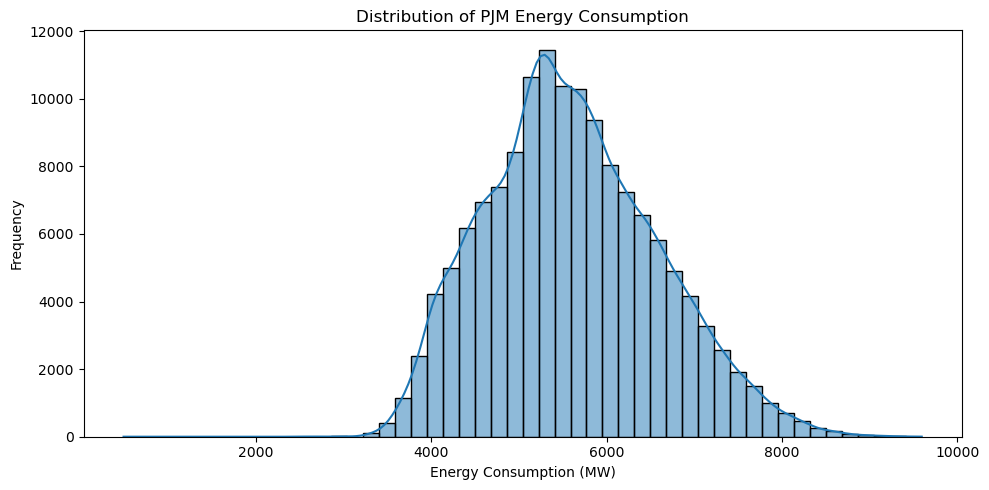

In [26]:
#Plotting the histogram for the (Frequency/Energy Consumption (MW))
plt.figure(figsize=(10, 5))

sns.histplot(
    df["PJMW_MW"],
    bins=50,
    kde=True
)

plt.title("Distribution of PJM Energy Consumption")
plt.xlabel("Energy Consumption (MW)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


#### INFERENCE:
The PJM energy consumption distribution is unimodal and slightly right-skewed. Most observations are concentrated around 4,000 to 7,000 MW, with peak frequency around 5,000–5,500 MW. Extremely high and low consumption values occur less frequently.”

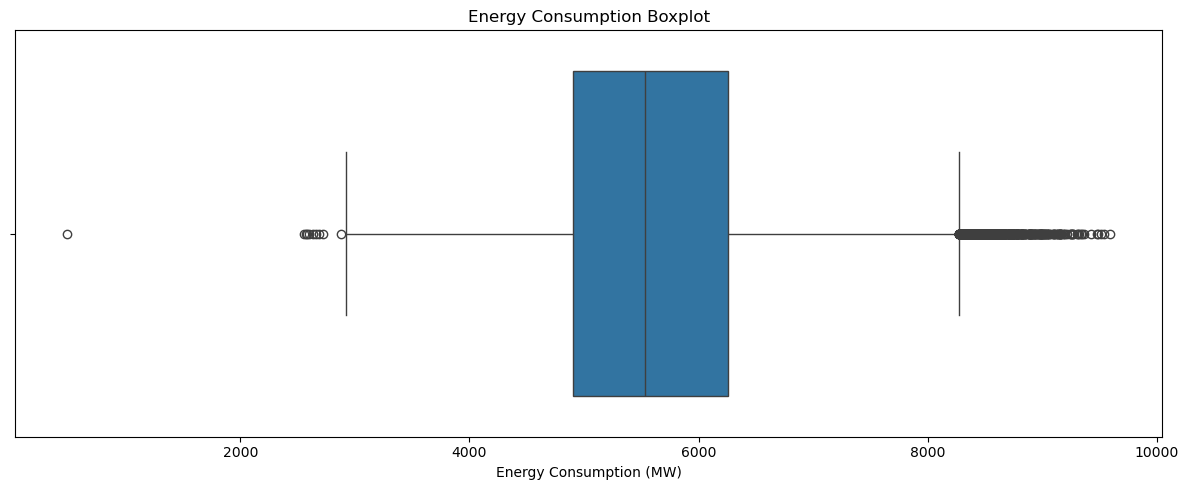

In [27]:
##Plotting the Boxplot for (Energy Consumption (MW))
plt.figure(figsize=(12, 5))

sns.boxplot(
    x=df["PJMW_MW"]
)

plt.title("Energy Consumption Boxplot")
plt.xlabel("Energy Consumption (MW)")

plt.tight_layout()
plt.show()


### INFERENCE:
The boxplot shows that PJM energy consumption is mainly concentrated between approximately 4,800 and 6,300 MW, with a median around 5,500 MW. There are several potential outliers, particularly on the higher side, indicating periods of unusually high energy consumption. A few low-end outliers are also present. These extreme values should be investigated to determine whether they represent genuine peak-demand periods or data anomalies.

### Outlier Analysis and Treatment

In [28]:
#OUTLIER DETEECTION USING THE (IQR).
#Calculates the first and third quartile(25th percentile, 75th percentile)
Q1 = df["PJMW_MW"].quantile(0.25)
Q3 = df["PJMW_MW"].quantile(0.75)

#Calculates the interquartile Range.
IQR = Q3 - Q1

#Calculates the lower and upper limits for detecting outliers.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Identify observations below the lower bound  or above the upper bound as potential outliers.
outliers = df[
    (df["PJMW_MW"] < lower_bound) |
    (df["PJMW_MW"] > upper_bound)
]

#Displays the calculated outliers boundries.
print("\nIQR Lower Bound:", lower_bound)
print("IQR Upper Bound:", upper_bound)

#Displays the number of potential outliers.
print("Potential Outliers:", len(outliers))



IQR Lower Bound: 2885.5
IQR Upper Bound: 8273.5
Potential Outliers: 695


###Outlier Treatment:
Potential outliers were identified using the IQR method. Since electricity consumption can naturally exhibit high-demand and low-demand periods, these observations were retained because extreme values may represent genuine peak demand rather than data errors.

#### INFERENCE:
The IQR method was used to identify potential outliers in PJM energy consumption. The observations outside the calculated lower and upper bounds are flagged as potential outliers. These values may represent periods of unusually high or low electricity demand, so they should be investigated rather than removed automatically.

### ADF TEST

In [29]:
## ADF Stationarity Test

In [30]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller test
adf_result = adfuller(df["PJMW_MW"].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags Used:", adf_result[2])
print("Number of Observations Used:", adf_result[3])

if adf_result[1] <= 0.05:
    print("\nResult: The series is stationary.")
else:
    print("\nResult: The series is non-stationary.")

ADF Statistic: -19.881056637387783
p-value: 0.0
Number of Lags Used: 74
Number of Observations Used: 142959

Result: The series is stationary.


## **Time-Series Stationarity Analysis**

### ACF Analysis

<Figure size 1200x500 with 0 Axes>

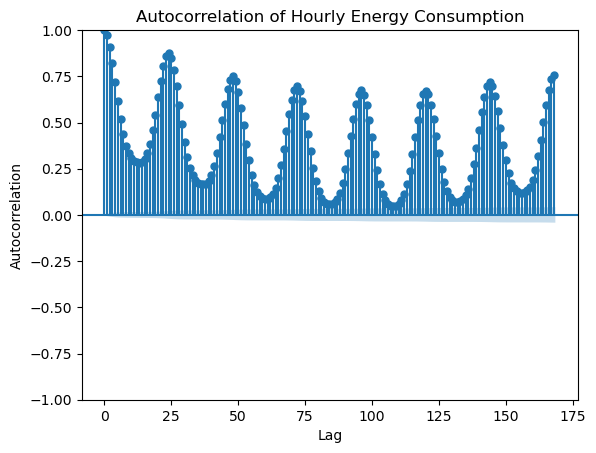

In [31]:
#importing the plot_acf from statsmodels.graphics.tsaplots
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))

plot_acf(
    df["PJMW_MW"].dropna(),
    lags=168
)

plt.title("Autocorrelation of Hourly Energy Consumption")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

### PACF Analysis

<Figure size 1200x500 with 0 Axes>

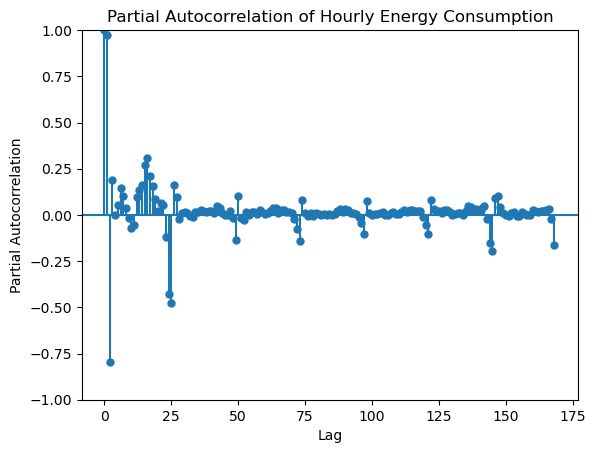

In [32]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12, 5))

plot_pacf(
    df["PJMW_MW"].dropna(),
    lags=168,
    method="ywm"
)

plt.title("Partial Autocorrelation of Hourly Energy Consumption")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.show()

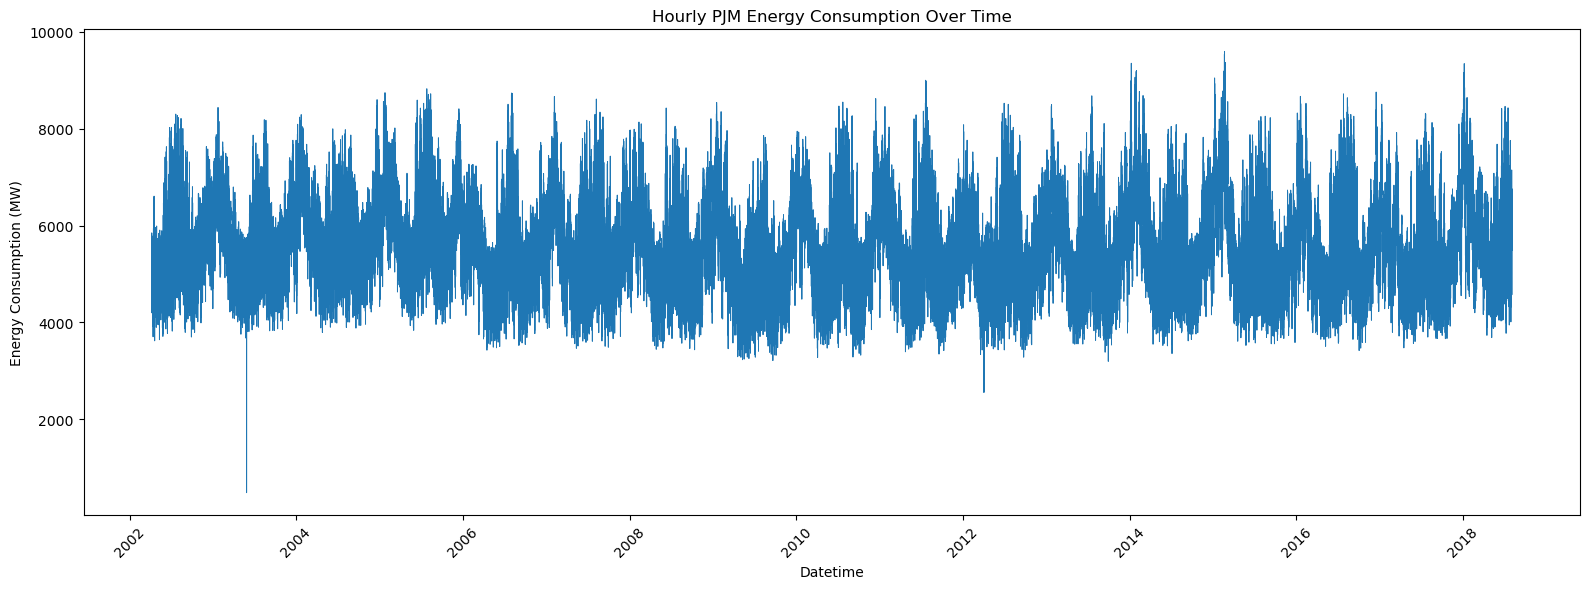

In [33]:
#plotting the time series  line plot.
plt.figure(figsize=(16, 6))

plt.plot(
    df["Datetime"],
    df["PJMW_MW"],
    linewidth=0.7
)

plt.title("Hourly PJM Energy Consumption Over Time")
plt.xlabel("Datetime")
plt.ylabel("Energy Consumption (MW)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


### INFERENCE:
The time-series plot shows that PJM energy consumption has a clear recurring pattern with frequent fluctuations throughout the period. Consumption generally ranges between approximately 4,000 and 8,000 MW, with occasional peaks reaching around 9,000–10,000 MW. The repeated patterns suggest strong seasonal and daily variations in electricity demand. Overall, there is no clear long-term upward or downward trend, while some extreme peaks and dips indicate periods of unusually high or low consumption.


Average Consumption by Hour:


,Average_Consumption_MW
Hour,
0,5230.544631
1,4940.632718
2,4779.598084
3,4697.112363
4,4672.453447
5,4734.841973
6,4958.053682
7,5323.287032
8,5571.048314


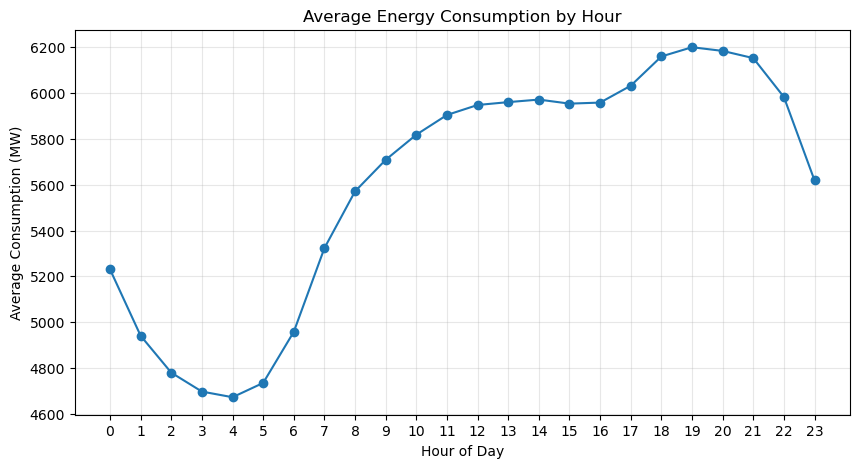

In [34]:
#Hourly average energy consumption plot.
hourly_avg = (
    df.groupby("Hour")["PJMW_MW"]
    .mean()
)

print("\nAverage Consumption by Hour:")
display(
    hourly_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_avg.index,
    hourly_avg.values,
    marker="o"
)

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (MW)")

plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()


### INDERENCE:
The plot shows a clear daily pattern in energy consumption. Consumption is lowest during the early morning hours, reaching its minimum around 4 AM. It then steadily increases through the morning and reaches a high level during the afternoon and evening. The peak occurs around 7–8 PM, after which consumption decreases, with a noticeable drop during the late evening. This indicates strong daily/diurnal seasonality in electricity demand.


Average Consumption by Day:


,Average_Consumption_MW
Day_Name,
Monday,5701.098063
Tuesday,5801.652729
Wednesday,5802.929920
Thursday,5780.970217
Friday,5686.840041
Saturday,5293.912701
Sunday,5149.935870


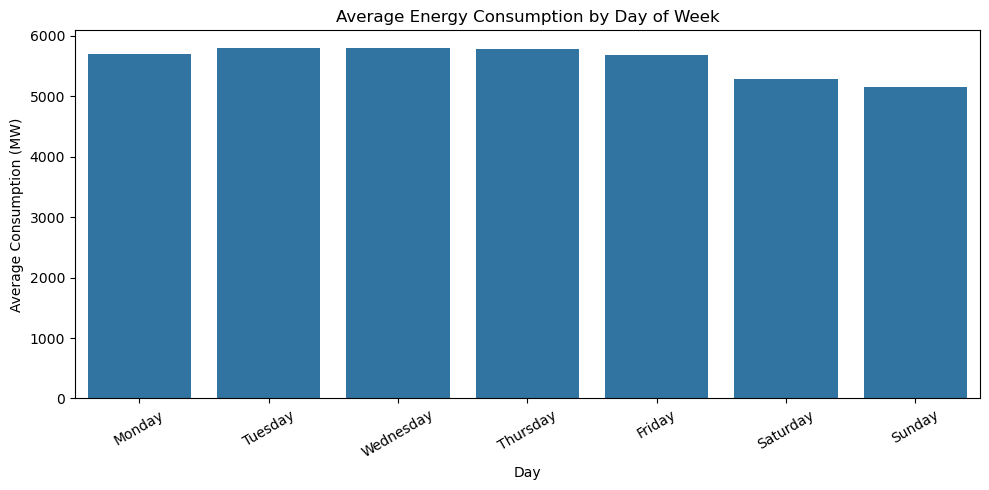

In [35]:
#Plotting bar chart for average PJM energy consumption by day of the week.
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_avg = (
    df.groupby("Day_Name")["PJMW_MW"]
    .mean()
    .reindex(day_order)
)

print("\nAverage Consumption by Day:")
display(
    day_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_avg.index,
    y=day_avg.values
)

plt.title("Average Energy Consumption by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Consumption (MW)")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()


### INFERENCE:
The chart shows that average energy consumption is relatively consistent from Monday to Friday, with Wednesday and Thursday having slightly higher consumption. Consumption decreases noticeably on Saturday and Sunday. This indicates a weekly pattern, where energy demand is generally higher on weekdays and lower during weekends.

Weekday Average: 5754.7151760032875
Weekend Average: 5221.973664870162


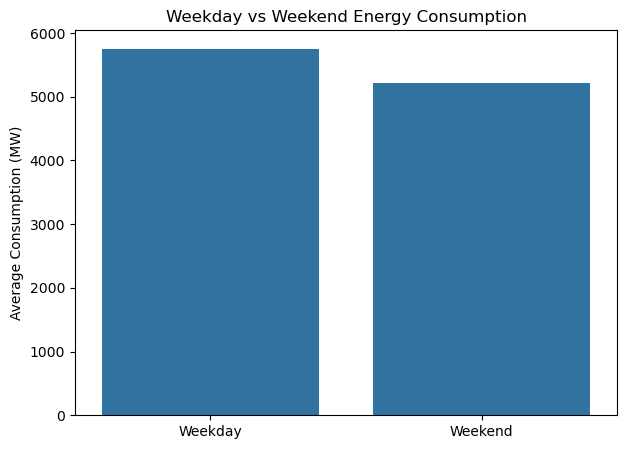

In [36]:
#plotting Comparission plot by bar chart.
weekend_avg = (
    df.groupby("Weekend")["PJMW_MW"]
    .mean()
)

print(
    "Weekday Average:",
    weekend_avg.get(False, np.nan)
)

print(
    "Weekend Average:",
    weekend_avg.get(True, np.nan)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=["Weekday", "Weekend"],
    y=[
        weekend_avg.get(False, np.nan),
        weekend_avg.get(True, np.nan)
    ]
)

plt.title("Weekday vs Weekend Energy Consumption")
plt.ylabel("Average Consumption (MW)")

plt.show()


### INFERENCE:
The chart shows that average energy consumption is higher on weekdays, at approximately 5,750 MW, compared with around 5,200 MW on weekends. This indicates that electricity demand is higher during weekdays and decreases during weekends, showing a clear weekday–weekend consumption pattern.


Average Consumption by Month:


,Average_Consumption_MW
Month,
1,6447.667759
2,6296.808813
3,5654.097376
4,5017.339798
5,5015.845746
6,5516.756046
7,5861.537081
8,5822.142809
9,5205.872049


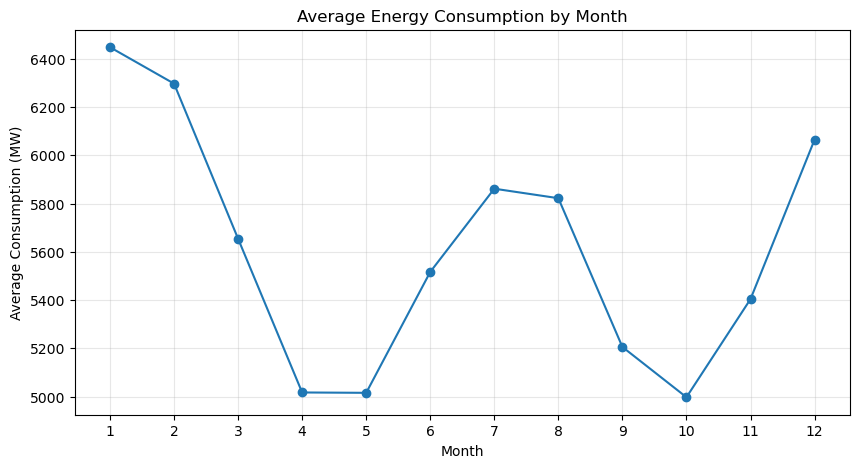

In [37]:
monthly_avg = (
    df.groupby("Month")["PJMW_MW"]
    .mean()
)

print("\nAverage Consumption by Month:")
display(
    monthly_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.title("Average Energy Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Consumption (MW)")

plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

plt.show()


### INFERNEC:
Energy consumption varies considerably across months. It is highest in January and December, while it reaches lower levels around April–May and October, indicating a clear monthly/seasonal pattern in electricity demand.


Average Consumption by Year:


,Average_Consumption_MW
Year,
2002,5627.995489
2003,5700.628226
2004,5866.616602
2005,6038.406029
2006,5425.448847
2007,5635.396780
2008,5530.132544
2009,5290.557433
2010,5573.025351


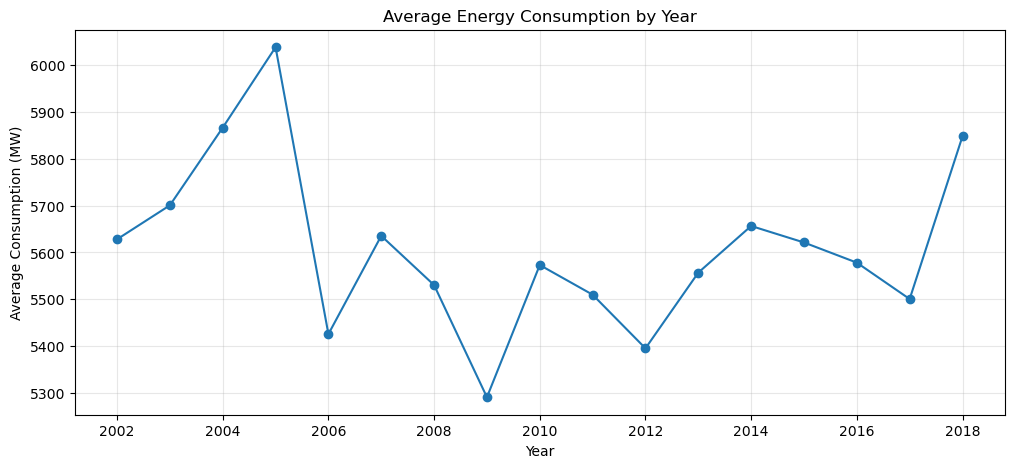

In [38]:


yearly_avg = (
    df.groupby("Year")["PJMW_MW"]
    .mean()
)

print("\nAverage Consumption by Year:")
display(
    yearly_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(12, 5))

plt.plot(
    yearly_avg.index,
    yearly_avg.values,
    marker="o"
)

plt.title("Average Energy Consumption by Year")
plt.xlabel("Year")
plt.ylabel("Average Consumption (MW)")

plt.grid(True, alpha=0.3)

plt.show()

#### INFERENCE:
The yearly average shows noticeable fluctuations rather than a consistent upward or downward trend. Consumption peaks around 2005, declines afterward, and fluctuates through the later years, with an increase again in 2018.


Average Consumption by Season:


,Average_Consumption_MW
Season,
Winter,6268.813851
Spring,5223.683686
Summer,5734.206129
Autumn,5200.264085


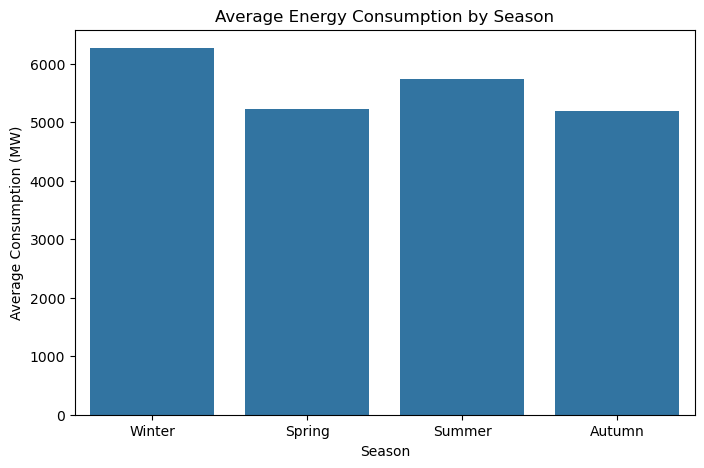

In [39]:

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

season_avg = (
    df.groupby("Season")["PJMW_MW"]
    .mean()
    .reindex(season_order)
)

print("\nAverage Consumption by Season:")
display(
    season_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_avg.index,
    y=season_avg.values
)

plt.title("Average Energy Consumption by Season")
plt.xlabel("Season")
plt.ylabel("Average Consumption (MW)")

plt.show()


#### INFERENCE:
Winter has the highest average energy consumption, followed by summer. Spring and autumn show comparatively lower consumption. This indicates that seasonal conditions have a significant influence on electricity demand.

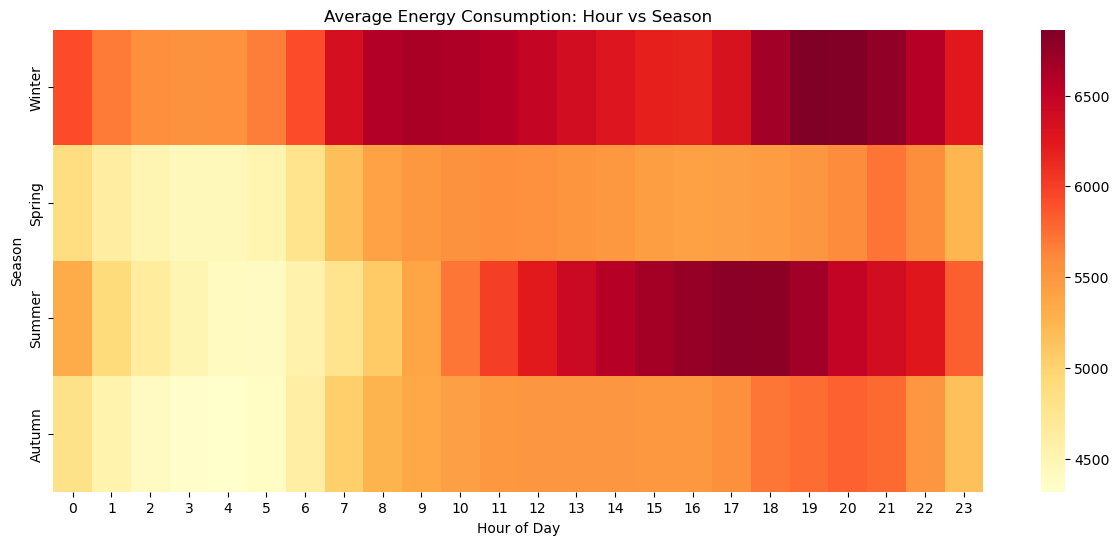

In [40]:
hour_season = df.pivot_table(
    values="PJMW_MW",
    index="Season",
    columns="Hour",
    aggfunc="mean"
)

hour_season = hour_season.reindex(
    season_order
)

plt.figure(figsize=(15, 6))

sns.heatmap(
    hour_season,
    cmap="YlOrRd"
)

plt.title(
    "Average Energy Consumption: Hour vs Season"
)

plt.xlabel("Hour of Day")
plt.ylabel("Season")

plt.show()


#### INFERENCE:
Energy consumption varies by both hour of the day and season. Winter generally shows higher consumption, particularly during later hours, while spring and autumn have relatively lower levels. This indicates an interaction between seasonal and daily demand patterns.

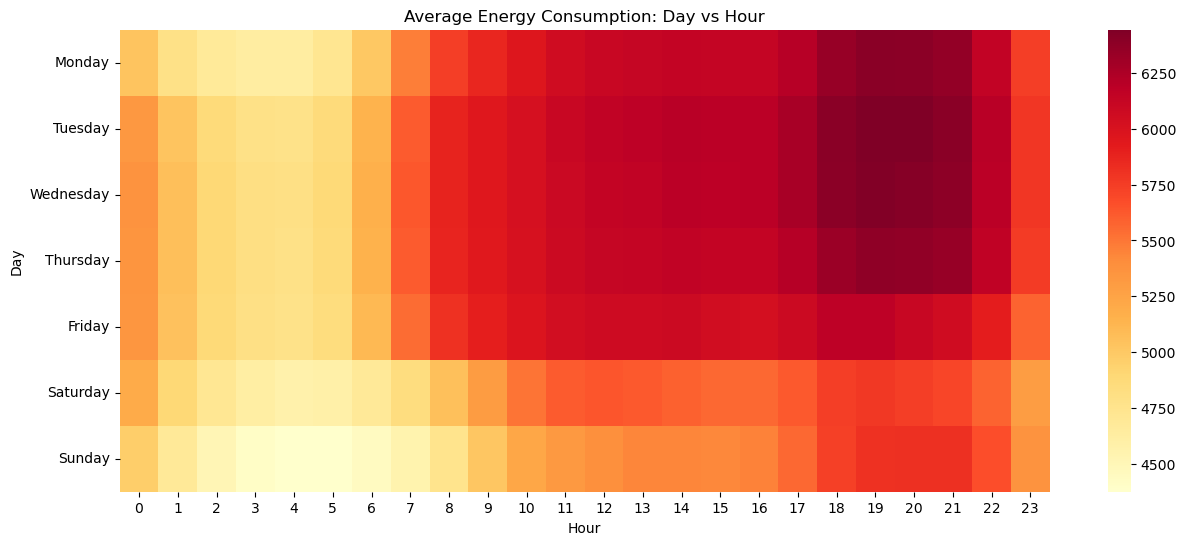

In [41]:
day_hour = df.pivot_table(
    values="PJMW_MW",
    index="Day_Name",
    columns="Hour",
    aggfunc="mean"
)

day_hour = day_hour.reindex(
    day_order
)

plt.figure(figsize=(15, 6))

sns.heatmap(
    day_hour,
    cmap="YlOrRd"
)

plt.title(
    "Average Energy Consumption: Day vs Hour"
)

plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()

### INFERENCE:
Energy consumption is generally lower during the early morning hours and increases from around 7–8 AM. It remains high throughout the daytime and evening, with particularly high consumption on weekdays. Weekend consumption is comparatively lower.

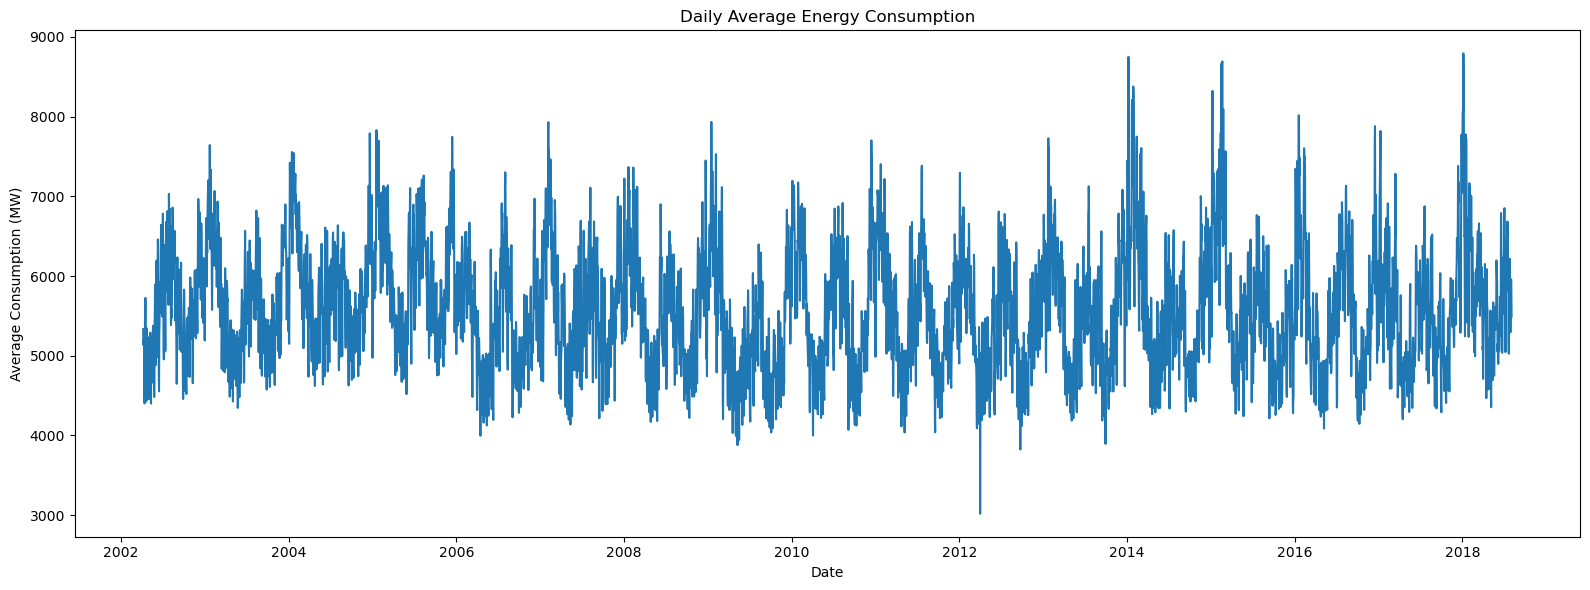

In [42]:
daily_avg = (
    df.set_index("Datetime")["PJMW_MW"]
    .resample("D")
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    daily_avg.index,
    daily_avg.values
)

plt.title("Daily Average Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Average Consumption (MW)")

plt.tight_layout()
plt.show()


#### INFERENCE:
Daily consumption shows substantial short-term fluctuations throughout the period. The series repeatedly rises and falls, with occasional high peaks and low values, indicating strong daily variability and recurring patterns in energy demand.

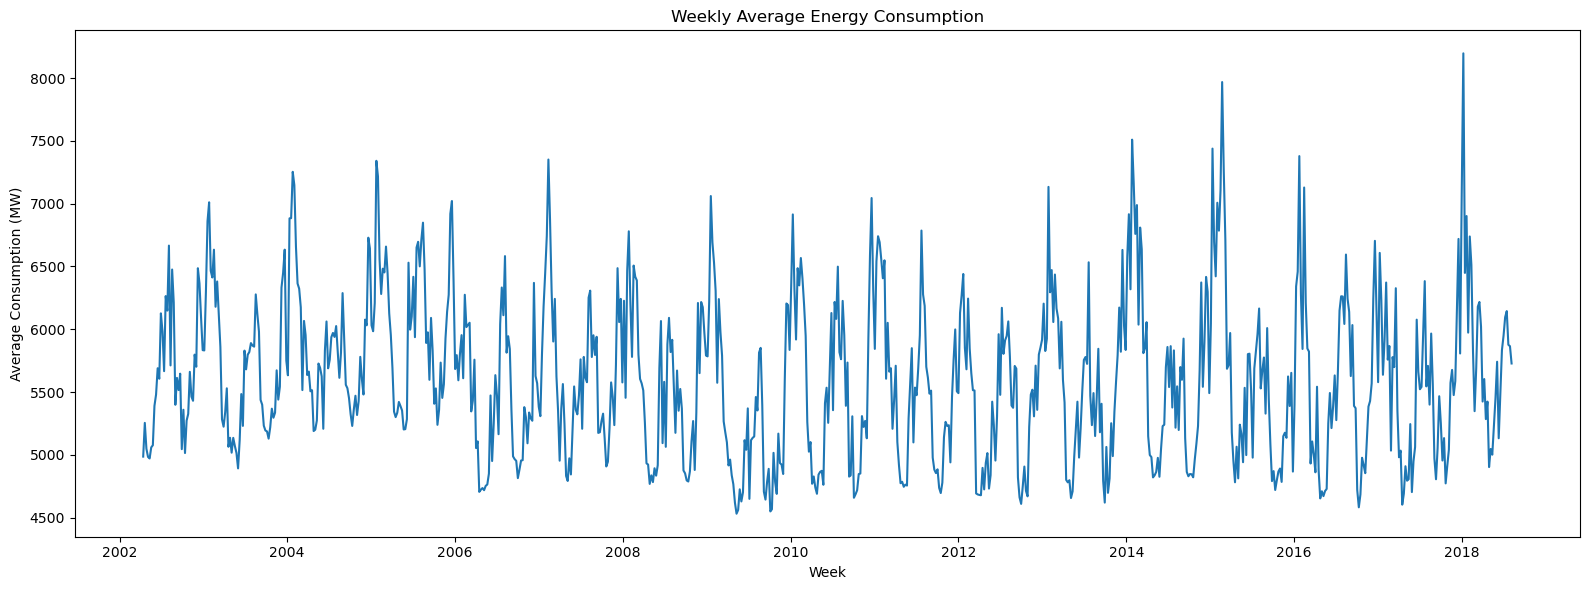

In [43]:
weekly_avg = (
    df.set_index("Datetime")["PJMW_MW"]
    .resample("W")
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    weekly_avg.index,
    weekly_avg.values
)

plt.title("Weekly Average Energy Consumption")
plt.xlabel("Week")
plt.ylabel("Average Consumption (MW)")

plt.tight_layout()
plt.show()

#### INFERENCE:
Weekly consumption also shows recurring fluctuations, with regular peaks and troughs. The overall level remains relatively stable across the years, suggesting repeating weekly patterns rather than a strong long-term trend.

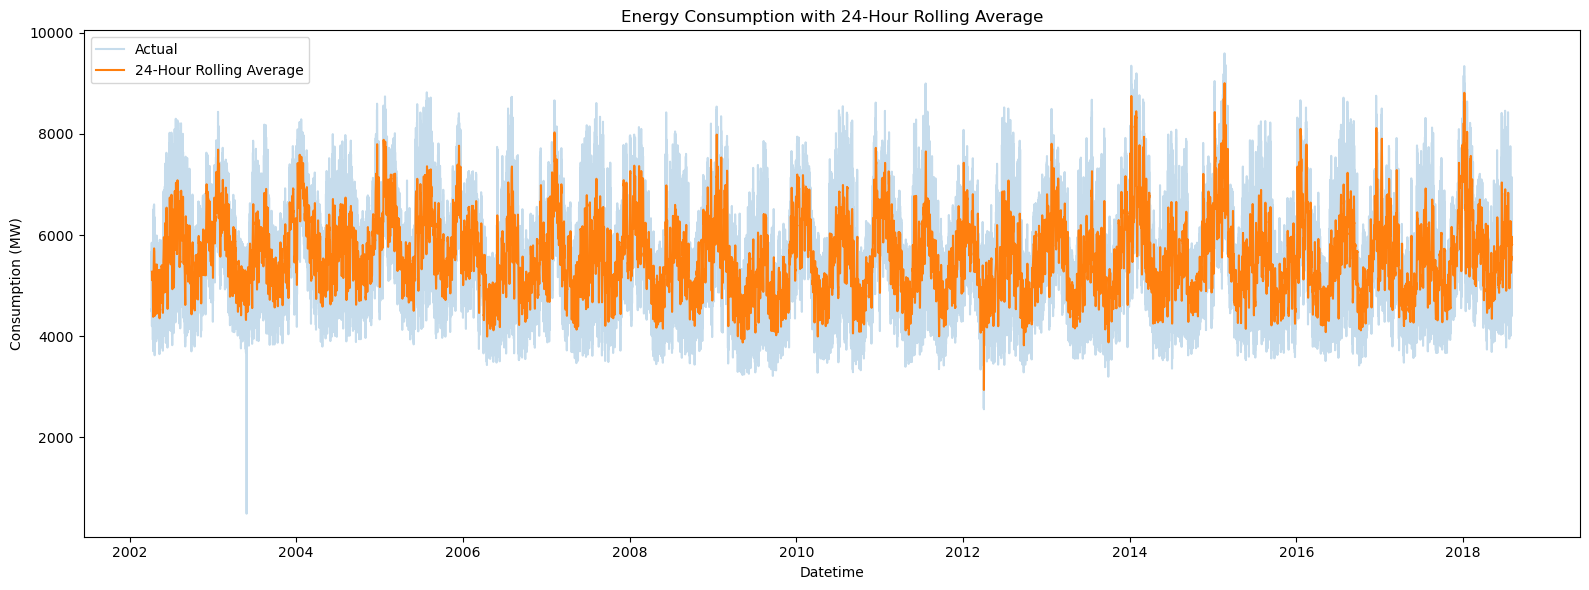

In [44]:
# Creating leakage-safe rolling averages for visualization

rolling_24h_plot = (
    df["PJMW_MW"]
    .shift(1)
    .rolling(24)
    .mean()
)

rolling_7d_plot = (
    df["PJMW_MW"]
    .shift(1)
    .rolling(168)
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    df["Datetime"],
    df["PJMW_MW"],
    alpha=0.25,
    label="Actual"
)

plt.plot(
    df["Datetime"],
    rolling_24h_plot,
    label="24-Hour Rolling Average"
)

plt.title("Energy Consumption with 24-Hour Rolling Average")
plt.xlabel("Datetime")
plt.ylabel("Consumption (MW)")
plt.legend()

plt.tight_layout()
plt.show()

#### INFERENCE:
The 24-hour rolling average smooths the short-term fluctuations in actual energy consumption. It clearly reveals the underlying consumption pattern while reducing the effect of individual hourly peaks and drops. This can be useful for identifying the general trend before forecasting.

In [45]:
df["Lag_1_Hour"] = df["PJMW_MW"].shift(1)
df["Lag_24_Hours"] = df["PJMW_MW"].shift(24)
df["Lag_48_Hours"] = df["PJMW_MW"].shift(48)
df["Lag_168_Hours"] = df["PJMW_MW"].shift(168)

lag_columns = [
    "PJMW_MW",
    "Lag_1_Hour",
    "Lag_24_Hours",
    "Lag_48_Hours",
    "Lag_168_Hours"
]

print("\nLag Correlations:")
display(
    df[lag_columns].corr()
)



Lag Correlations:


,PJMW_MW,Lag_1_Hour,Lag_24_Hours,Lag_48_Hours,Lag_168_Hours
PJMW_MW,1.000000,0.974691,0.877210,0.750437,0.759371
Lag_1_Hour,0.974691,1.000000,0.860024,0.732817,0.737791
Lag_24_Hours,0.877210,0.860024,1.000000,0.877198,0.719295
Lag_48_Hours,0.750437,0.732817,0.877198,1.000000,0.673040
Lag_168_Hours,0.759371,0.737791,0.719295,0.673040,1.000000


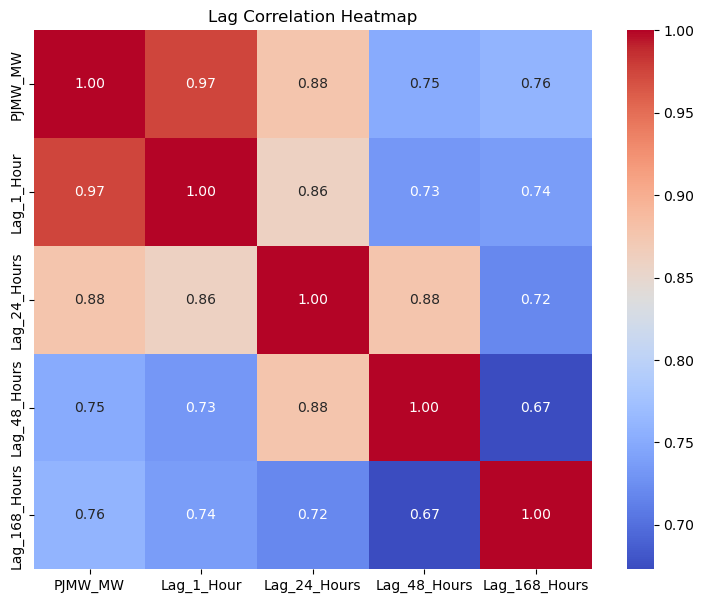

In [46]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    df[lag_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Lag Correlation Heatmap")

plt.show()



#### INFERENCE:
The heatmap shows strong positive correlations between current consumption and lagged consumption. The correlation is highest for shorter lags, such as 1 hour (0.97), and gradually decreases for longer lags, reaching around 0.76 at 168 hours. This indicates strong temporal dependence and suggests that previous energy consumption values can be useful predictors for forecasting.

In [47]:
#Final Feature Selection.
features = [
    "Year",
    "Month",
    "Day",
    "Hour",
    "Day_of_Week",
    "Quarter",
    "Week",
    "Weekend",
    "Lag_1_Hour",
    "Lag_24_Hours",
    "Lag_48_Hours",
    "Lag_168_Hours",
    "Rolling_24H",
    "Rolling_7D"
]

X = df[features]
y = df["PJMW_MW"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (143034, 14)
Target shape: (143034,)


In [48]:
# Chronological train-test split

train_size = int(len(df) * 0.80)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining period:")
print(df["Datetime"].iloc[:train_size].min())
print("to")
print(df["Datetime"].iloc[train_size - 1])

print("\nTesting period:")
print(df["Datetime"].iloc[train_size])
print("to")
print(df["Datetime"].iloc[-1])

Training data: (114427, 14)
Testing data: (28607, 14)

Training period:
2002-04-08 02:00:00
to
2015-04-28 22:00:00

Testing period:
2015-04-28 23:00:00
to
2018-08-03 00:00:00


#### Scaling the Features.

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (114427, 14)
Scaled testing shape: (28607, 14)


# Model Building

## ARIMA and SARIMA Model Building
The models use the daily-average time series `daily_avg` prepared during the EDA stage.

The original PJM dataset contains hourly observations. However, the EDA stage has already prepared a daily-average series. Therefore, the modeling stage uses this existing EDA-prepared series.


In [50]:
# ============================================================
# ARIMA / SARIMA MODELING - IMPORTS
# ============================================================

import itertools
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [51]:
# ============================================================
# USE EDA-PREPARED DAILY SERIES
# ============================================================
# Use the daily-average series already created during EDA.

daily = daily_avg.copy()

# Ensure chronological ordering
daily.index = pd.to_datetime(daily.index)
daily = daily.sort_index()

print("EDA-prepared modelling series:")
display(daily.head())

print("\nData type:")
print(type(daily))

print("\nNumber of observations:")
print(len(daily))

print("\nStart date:")
print(daily.index.min())

print("\nEnd date:")
print(daily.index.max())

print("\nMissing values:")
print(daily.isna().sum())

EDA-prepared modelling series:


Datetime
2002-04-08    5335.500000
2002-04-09    5136.083333
2002-04-10    5171.666667
2002-04-11    5207.875000
2002-04-12    5090.416667
Freq: D, Name: PJMW_MW, dtype: float64


Data type:
<class 'pandas.core.series.Series'>

Number of observations:
5962

Start date:
2002-04-08 00:00:00

End date:
2018-08-03 00:00:00

Missing values:
0


In [52]:
# ============================================================
# VERIFY MODELING FREQUENCY
# ============================================================

time_difference = (
    daily.index.to_series()
    .diff()
    .dropna()
)

print("Most common time interval:")
print(time_difference.mode().iloc[0])

print("\nTime interval counts:")
display(
    time_difference.value_counts().head()
)

print("\nInferred frequency:")
print(pd.infer_freq(daily.index))

Most common time interval:
1 days 00:00:00

Time interval counts:


Datetime
1 days    5961
Name: count, dtype: int64


Inferred frequency:
D


## Modeling Frequency

The original PJM energy consumption data is hourly.

However, the EDA stage already created the `daily_avg` series by calculating the daily mean consumption from the cleaned hourly data.

Therefore, ARIMA and SARIMA are developed using the EDA-prepared daily series.

For the modeling data:

- 1 observation = 1 day
- 7 observations = 1 week
- Approximately 365 observations = 1 year

The EDA identified weekly patterns in energy consumption. Therefore, the seasonal period for SARIMA is represented by 7 daily observations.

### Chronological train/test split

In [53]:

test_size = 365

train_daily = daily.iloc[:-test_size].copy()
test_daily = daily.iloc[-test_size:].copy()

print("Training observations:", len(train_daily))
print("Testing observations :", len(test_daily))

print("\nTraining period:")
print(
    train_daily.index.min(),
    "to",
    train_daily.index.max()
)

print("\nTesting period:")
print(
    test_daily.index.min(),
    "to",
    test_daily.index.max()
)

# Verify chronological order
assert train_daily.index.max() < test_daily.index.min()

print("\nChronological train-test split verified.")

Training observations: 5597
Testing observations : 365

Training period:
2002-04-08 00:00:00 to 2017-08-03 00:00:00

Testing period:
2017-08-04 00:00:00 to 2018-08-03 00:00:00

Chronological train-test split verified.


### Train/test visualization

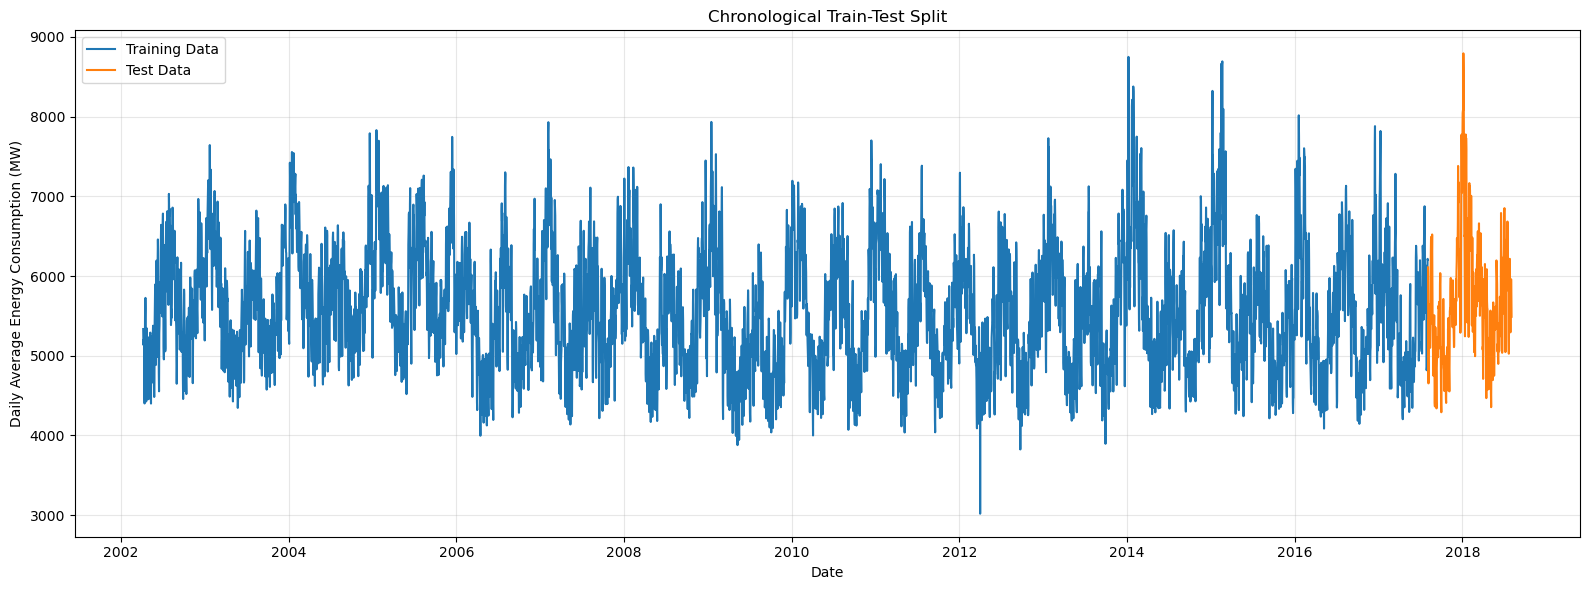

In [54]:
plt.figure(figsize=(16, 6))

plt.plot(
    train_daily.index,
    train_daily.values,
    label="Training Data"
)

plt.plot(
    test_daily.index,
    test_daily.values,
    label="Test Data"
)

plt.title(
    "Chronological Train-Test Split"
)

plt.xlabel("Date")
plt.ylabel(
    "Daily Average Energy Consumption (MW)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Stationarity test

ARIMA requires the time series to be stationary or transformed into a stationary series.

The Augmented Dickey-Fuller (ADF) test is used to assess stationarity.

If the p-value is less than or equal to 0.05, the null hypothesis of non-stationarity is rejected.

The differencing order `d` is selected based on the stationarity of the training series.

In [55]:
# ============================================================
# ADF STATIONARITY TEST
# ============================================================

def run_adf(series, name):

    series = series.dropna()

    result = adfuller(
        series,
        autolag="AIC"
    )

    print(f"\nADF Test: {name}")
    print("-" * 45)

    print(
        f"ADF Statistic : {result[0]:.4f}"
    )

    print(
        f"p-value       : {result[1]:.4f}"
    )

    print(
        f"Lags Used     : {result[2]}"
    )

    print(
        f"Observations  : {result[3]}"
    )

    if result[1] <= 0.05:
        print(
            "Result: The series is stationary."
        )
    else:
        print(
            "Result: The series is non-stationary."
        )

    return result[1]

In [56]:
# ============================================================
# DETERMINE ARIMA DIFFERENCING ORDER d
# ============================================================

p_level = run_adf(
    train_daily,
    "Original Training Series"
)

p_first_diff = run_adf(
    train_daily.diff(),
    "First-Differenced Training Series"
)

if p_level <= 0.05:
    d = 0
else:
    d = 1

print("\nSelected ARIMA differencing order:")
print("d =", d)


ADF Test: Original Training Series
---------------------------------------------
ADF Statistic : -7.1489
p-value       : 0.0000
Lags Used     : 33
Observations  : 5563
Result: The series is stationary.

ADF Test: First-Differenced Training Series
---------------------------------------------
ADF Statistic : -16.4174
p-value       : 0.0000
Lags Used     : 32
Observations  : 5563
Result: The series is stationary.

Selected ARIMA differencing order:
d = 0


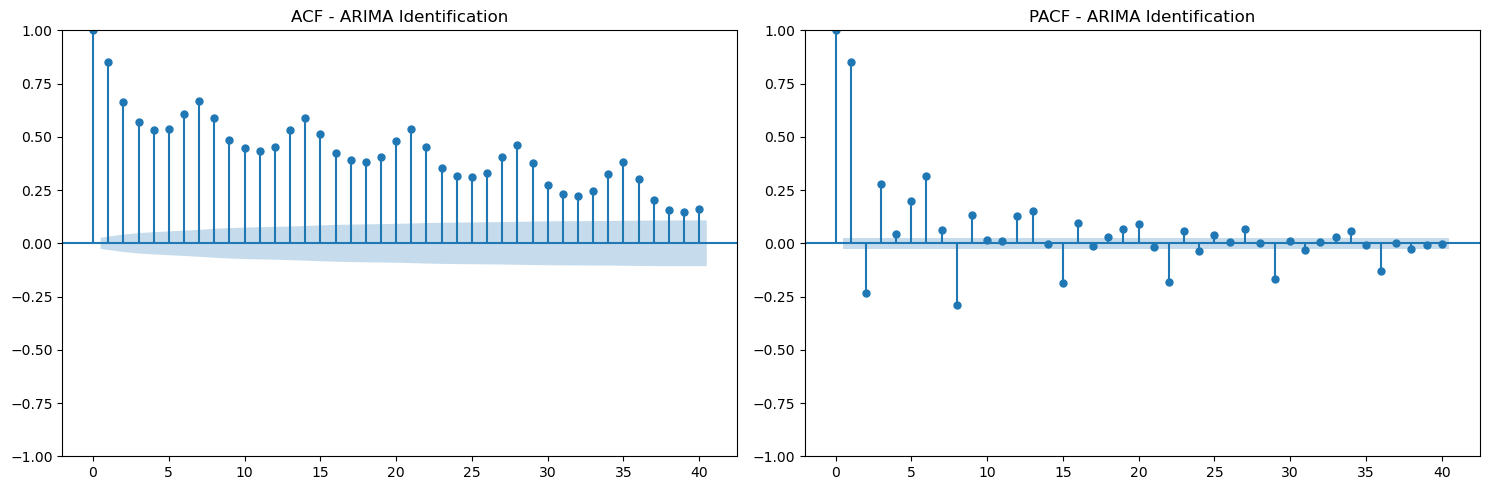

In [57]:
# ============================================================
# ACF / PACF FOR ARIMA IDENTIFICATION
# ============================================================

if d == 1:
    arima_identification_series = (
        train_daily.diff().dropna()
    )
else:
    arima_identification_series = train_daily.copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

plot_acf(
    arima_identification_series,
    lags=40,
    ax=axes[0]
)

plot_pacf(
    arima_identification_series,
    lags=40,
    method="ywm",
    ax=axes[1]
)

axes[0].set_title(
    "ACF - ARIMA Identification"
)

axes[1].set_title(
    "PACF - ARIMA Identification"
)

plt.tight_layout()
plt.show()

## ARIMA Parameter Selection

ARIMA is represented as:

ARIMA(p,d,q)

where:

- `p` = autoregressive order
- `d` = differencing order
- `q` = moving-average order

The ADF test is used to determine `d`.

The ACF and PACF plots provide initial guidance for possible values of `p` and `q`.

However, the final `p` and `q` values are selected through systematic hyperparameter tuning using AIC.

## ARIMA hyperparameter tuning

In [58]:
# ============================================================
# ARIMA HYPERPARAMETER TUNING
# ============================================================

p_values = range(0, 4)
q_values = range(0, 4)

arima_results = []

start_time = time.time()

for p, q in itertools.product(
    p_values,
    q_values
):

    order = (
        p,
        d,
        q
    )

    try:

        model = ARIMA(
            train_daily,
            order=order
        )

        fitted_model = model.fit()

        arima_results.append({
            "p": p,
            "d": d,
            "q": q,
            "order": order,
            "AIC": fitted_model.aic
        })

    except Exception as e:

        print(
            f"ARIMA{order} failed: {e}"
        )


arima_table = (
    pd.DataFrame(arima_results)
    .sort_values("AIC")
    .reset_index(drop=True)
)

elapsed_time = (
    time.time() - start_time
) / 60

print(
    f"ARIMA tuning completed in "
    f"{elapsed_time:.2f} minutes."
)

print("\nARIMA hyperparameter results:")

display(arima_table)

ARIMA tuning completed in 1.64 minutes.

ARIMA hyperparameter results:


,p,d,q,order,AIC
0,3,0,3,"(3, 0, 3)",81371.404794
1,2,0,3,"(2, 0, 3)",81416.521601
2,1,0,3,"(1, 0, 3)",81416.626591
3,3,0,1,"(3, 0, 1)",81453.288088
4,2,0,2,"(2, 0, 2)",81460.167248
5,3,0,2,"(3, 0, 2)",81478.704256
6,1,0,2,"(1, 0, 2)",81747.689112
7,3,0,0,"(3, 0, 0)",81753.081860
8,2,0,1,"(2, 0, 1)",81901.814679
9,1,0,1,"(1, 0, 1)",81942.176500


### SELECT BEST ARIMA MODEL

In [59]:
best_arima_order = (
    arima_table.loc[0, "order"]
)

best_arima_aic = (
    arima_table.loc[0, "AIC"]
)

print(
    "Best ARIMA order selected by AIC:"
)

print(
    best_arima_order
)

print(
    "\nBest ARIMA AIC:"
)

print(
    best_arima_aic
)

Best ARIMA order selected by AIC:
(3, 0, 3)

Best ARIMA AIC:
81371.40479390166


### TOP ARIMA MODELS

In [60]:
print("Top 10 ARIMA models:")

display(
    arima_table.head(10)
)

Top 10 ARIMA models:


,p,d,q,order,AIC
0,3,0,3,"(3, 0, 3)",81371.404794
1,2,0,3,"(2, 0, 3)",81416.521601
2,1,0,3,"(1, 0, 3)",81416.626591
3,3,0,1,"(3, 0, 1)",81453.288088
4,2,0,2,"(2, 0, 2)",81460.167248
5,3,0,2,"(3, 0, 2)",81478.704256
6,1,0,2,"(1, 0, 2)",81747.689112
7,3,0,0,"(3, 0, 0)",81753.081860
8,2,0,1,"(2, 0, 1)",81901.814679
9,1,0,1,"(1, 0, 1)",81942.176500


## Final ARIMA model

In [61]:
# ============================================================
# FINAL ARIMA MODEL
# ============================================================

arima_fit = ARIMA(
    train_daily,
    order=best_arima_order
).fit()

print(
    "Final ARIMA model fitted successfully."
)

print(
    "\nSelected ARIMA order:"
)

print(
    best_arima_order
)

print(
    "\nFinal ARIMA AIC:"
)

print(
    arima_fit.aic
)

Final ARIMA model fitted successfully.

Selected ARIMA order:
(3, 0, 3)

Final ARIMA AIC:
81371.40479390166


In [62]:
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                PJMW_MW   No. Observations:                 5597
Model:                 ARIMA(3, 0, 3)   Log Likelihood              -40677.702
Date:                Wed, 30 Sep 2026   AIC                          81371.405
Time:                        01:52:59   BIC                          81424.445
Sample:                    04-08-2002   HQIC                         81389.889
                         - 08-03-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5596.2625     71.340     78.445      0.000    5456.439    5736.086
ar.L1          1.9445      0.063     30.859      0.000       1.821       2.068
ar.L2         -1.3733      0.084    -16.320      0.0

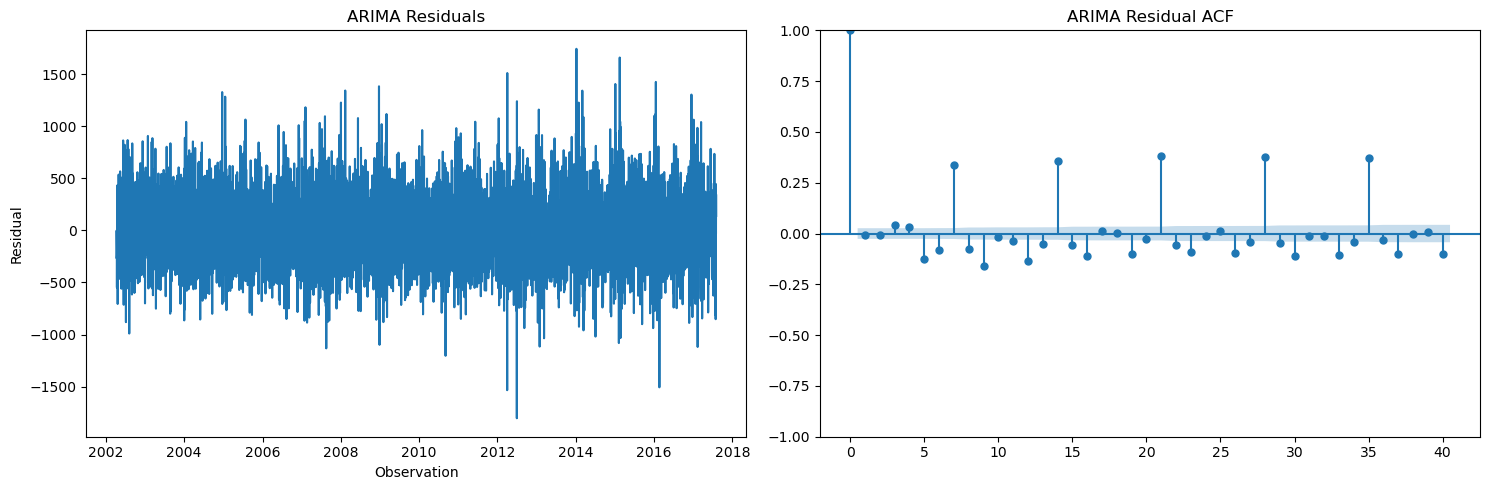

,lb_stat,lb_pvalue
7,781.615193,1.720000e-164
14,1793.082029,0.000000e+00
21,2766.258672,0.000000e+00
28,3693.073043,0.000000e+00


In [63]:
# ============================================================
# ARIMA RESIDUAL DIAGNOSTICS
# ============================================================

from statsmodels.stats.diagnostic import acorr_ljungbox

arima_residuals = arima_fit.resid.dropna()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

axes[0].plot(arima_residuals)
axes[0].set_title("ARIMA Residuals")
axes[0].set_xlabel("Observation")
axes[0].set_ylabel("Residual")

plot_acf(
    arima_residuals,
    lags=40,
    ax=axes[1]
)

axes[1].set_title("ARIMA Residual ACF")

plt.tight_layout()
plt.show()

ljung_box_arima = acorr_ljungbox(
    arima_residuals,
    lags=[7, 14, 21, 28],
    return_df=True
)

display(ljung_box_arima)

### ARIMA TEST-PERIOD FORECAST

In [64]:
arima_test_result = (
    arima_fit.get_forecast(
        steps=len(test_daily)
    )
)

arima_test_mean = (
    arima_test_result.predicted_mean
)

arima_test_ci = (
    arima_test_result.conf_int()
)

arima_test_forecast_df = pd.DataFrame(
    {
        "Actual": test_daily.values,
        "Forecast": arima_test_mean.values,
        "Lower_CI": arima_test_ci.iloc[:, 0].values,
        "Upper_CI": arima_test_ci.iloc[:, 1].values
    },
    index=test_daily.index
)

arima_test_forecast_df.index.name = "Date"

display(
    arima_test_forecast_df.head(10)
)

,Actual,Forecast,Lower_CI,Upper_CI
Date,,,,
2017-08-04,6108.875000,5943.382031,5262.575434,6624.188627
2017-08-05,4997.000000,5741.249789,4754.215189,6728.284389
2017-08-06,4653.291667,5679.898502,4617.087167,6742.709836
2017-08-07,5245.791667,5703.902467,4624.156605,6783.648328
2017-08-08,5461.625000,5750.905745,4663.848343,6837.963147
2017-08-09,5462.750000,5783.864777,4686.940555,6880.788998
2017-08-10,5432.083333,5793.369784,4679.825371,6906.914197
2017-08-11,5647.041667,5786.105304,4650.379121,6921.831487
2017-08-12,5450.041667,5772.611162,4613.420175,6931.802149


## ARIMA TEST FORECAST VISUALIZATION

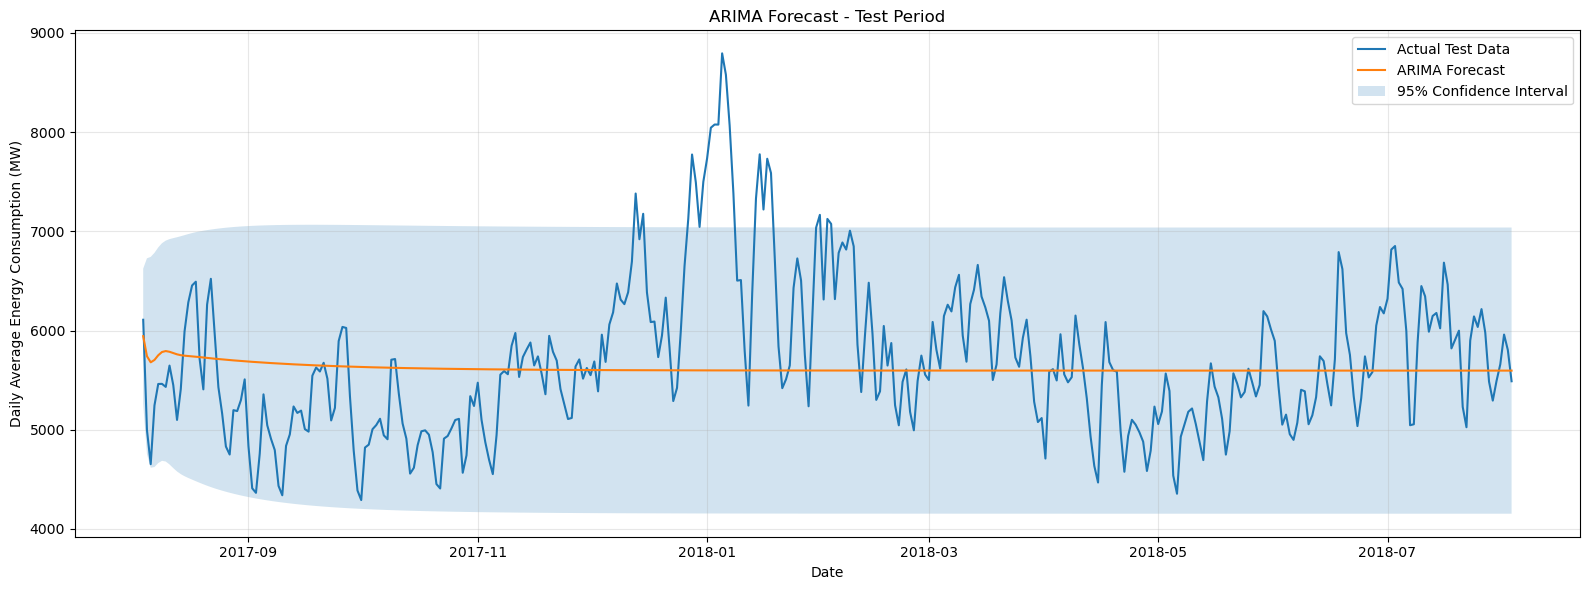

In [65]:
plt.figure(figsize=(16, 6))

plt.plot(
    test_daily.index,
    test_daily.values,
    label="Actual Test Data"
)

plt.plot(
    arima_test_forecast_df.index,
    arima_test_forecast_df["Forecast"],
    label="ARIMA Forecast"
)

plt.fill_between(
    arima_test_forecast_df.index,
    arima_test_forecast_df["Lower_CI"],
    arima_test_forecast_df["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(
    "ARIMA Forecast - Test Period"
)

plt.xlabel("Date")
plt.ylabel(
    "Daily Average Energy Consumption (MW)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# SARIMA Model

SARIMA extends ARIMA by explicitly modeling seasonal patterns.

The SARIMA model is represented as:

SARIMA(p,d,q)(P,D,Q,s)

where:

- `p` = regular autoregressive order
- `d` = regular differencing order
- `q` = regular moving-average order
- `P` = seasonal autoregressive order
- `D` = seasonal differencing order
- `Q` = seasonal moving-average order
- `s` = seasonal period

The EDA identified a weekly pattern in energy consumption.

Because the modeling series is daily:

1 week = 7 observations

Therefore, the SARIMA seasonal period is set to `s = 7`.

In [66]:
# ============================================================
# SARIMA SEASONAL PERIOD
# ============================================================

s = 7

print(
    "Selected SARIMA seasonal period:"
)

print(
    f"s = {s} observations"
)

print(
    "Interpretation: "
    "7 daily observations = 1 week."
)

Selected SARIMA seasonal period:
s = 7 observations
Interpretation: 7 daily observations = 1 week.


In [67]:
# ============================================================
# WEEKLY SEASONALITY CHECK
# ============================================================

changes = (
    train_daily.diff()
    .dropna()
)

acf_changes = acf(
    changes,
    nlags=60,
    fft=True
)

print(
    "ACF at weekly-related lags:"
)

for lag in [7, 14, 21, 28]:

    print(
        f"Lag {lag:2d}: "
        f"{acf_changes[lag]:.4f}"
    )

ACF at weekly-related lags:
Lag  7: 0.4653
Lag 14: 0.4553
Lag 21: 0.4639
Lag 28: 0.4653


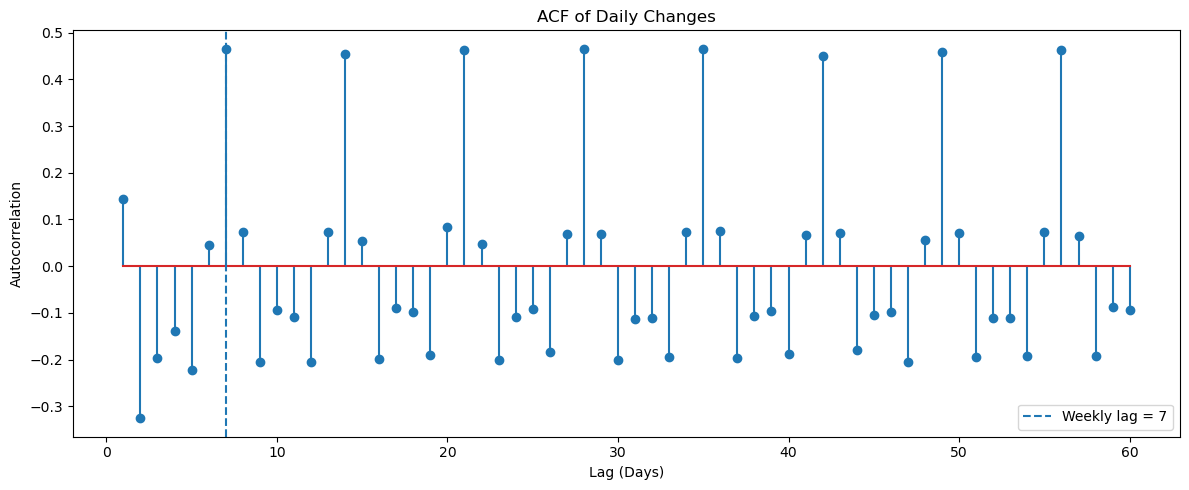

In [68]:
plt.figure(figsize=(12, 5))

plt.stem(
    range(1, 61),
    acf_changes[1:]
)

plt.axvline(
    7,
    linestyle="--",
    label="Weekly lag = 7"
)

plt.title(
    "ACF of Daily Changes"
)

plt.xlabel("Lag (Days)")
plt.ylabel("Autocorrelation")

plt.legend()

plt.tight_layout()
plt.show()

## Seasonal Differencing

The seasonal differencing order `D` is determined by applying the ADF test to the seasonally differenced training series.

Seasonal differencing is calculated using a seasonal lag of 7 observations because the modeling frequency is daily and the identified seasonal cycle is weekly.

In [69]:
# ============================================================
# DETERMINE SEASONAL DIFFERENCING D
# ============================================================

seasonal_diff = (
    train_daily
    .diff(s)
    .dropna()
)

p_seasonal_diff = run_adf(
    seasonal_diff,
    "Seasonally Differenced Training Series"
)

if p_seasonal_diff <= 0.05:
    D = 1
else:
    D = 0

print(
    "\nSelected seasonal differencing order:"
)

print(
    "D =", D
)


ADF Test: Seasonally Differenced Training Series
---------------------------------------------
ADF Statistic : -13.6546
p-value       : 0.0000
Lags Used     : 33
Observations  : 5556
Result: The series is stationary.

Selected seasonal differencing order:
D = 1


## SARIMA Hyperparameter Tuning

The SARIMA parameters are selected through systematic hyperparameter tuning using AIC.

The regular AR and MA orders are searched over:

- p = 0, 1, 2
- q = 0, 1, 2

The seasonal AR and MA orders are searched over:

- P = 0, 1
- Q = 0, 1

The regular differencing order `d`, seasonal differencing order `D`, and seasonal period `s` are determined before tuning.

The complete training dataset is used for hyperparameter tuning so that all available training observations contribute to model selection.

After selecting the best parameters, the final SARIMA model is fitted using the complete training dataset.

In [70]:
# ============================================================
# SARIMA HYPERPARAMETER TUNING
# ============================================================

# Use the complete training dataset for SARIMA hyperparameter tuning.
# for hyperparameter tuning.

tune_data = train_daily.copy()

print("SARIMA tuning data:")
print("Observations:", len(tune_data))
print("Start:", tune_data.index.min())
print("End:", tune_data.index.max())

p_values = range(0, 3)
q_values = range(0, 3)

P_values = range(0, 2)
Q_values = range(0, 2)

sarima_results = []

start_time = time.time()

for p, q, P, Q in itertools.product(
    p_values,
    q_values,
    P_values,
    Q_values
):

    order = (
        p,
        d,
        q
    )

    seasonal_order = (
        P,
        D,
        Q,
        s
    )

    try:

        model = SARIMAX(
            tune_data,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(
            disp=False
        )

        sarima_results.append(
            {
                "p": p,
                "d": d,
                "q": q,
                "P": P,
                "D": D,
                "Q": Q,
                "s": s,
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": fitted_model.aic
            }
        )

    except Exception as e:

        print(
            f"SARIMA{order} x "
            f"{seasonal_order} failed: {e}"
        )


sarima_table = (
    pd.DataFrame(sarima_results)
    .sort_values("AIC")
    .reset_index(drop=True)
)

elapsed_time = (
    time.time() - start_time
) / 60

print(
    f"SARIMA tuning completed in "
    f"{elapsed_time:.2f} minutes."
)

print(
    "\nSARIMA hyperparameter results:"
)

display(
    sarima_table
)

SARIMA tuning data:
Observations: 5597
Start: 2002-04-08 00:00:00
End: 2017-08-03 00:00:00
SARIMA tuning completed in 5.02 minutes.

SARIMA hyperparameter results:


,p,d,q,P,D,Q,s,order,seasonal_order,AIC
0,2,0,2,0,1,1,7,"(2, 0, 2)","(0, 1, 1, 7)",78477.066201
1,2,0,2,1,1,1,7,"(2, 0, 2)","(1, 1, 1, 7)",78590.535756
2,1,0,2,1,1,1,7,"(1, 0, 2)","(1, 1, 1, 7)",78651.565012
3,1,0,2,0,1,1,7,"(1, 0, 2)","(0, 1, 1, 7)",78656.408908
4,2,0,1,1,1,1,7,"(2, 0, 1)","(1, 1, 1, 7)",78700.432371
5,2,0,1,0,1,1,7,"(2, 0, 1)","(0, 1, 1, 7)",78715.717834
6,1,0,1,1,1,1,7,"(1, 0, 1)","(1, 1, 1, 7)",78721.067209
7,1,0,1,0,1,1,7,"(1, 0, 1)","(0, 1, 1, 7)",78742.860737
8,2,0,0,1,1,1,7,"(2, 0, 0)","(1, 1, 1, 7)",78842.332850
9,2,0,0,0,1,1,7,"(2, 0, 0)","(0, 1, 1, 7)",78883.375165


### SELECT BEST SARIMA MODEL

In [71]:
best_sarima_order = (
    sarima_table.loc[0, "order"]
)

best_sarima_seasonal = (
    sarima_table.loc[0, "seasonal_order"]
)

best_sarima_aic = (
    sarima_table.loc[0, "AIC"]
)

print(
    "Best SARIMA order:"
)

print(
    best_sarima_order
)

print(
    "\nBest seasonal order:"
)

print(
    best_sarima_seasonal
)

print(
    "\nBest SARIMA AIC:"
)

print(
    best_sarima_aic
)

Best SARIMA order:
(2, 0, 2)

Best seasonal order:
(0, 1, 1, 7)

Best SARIMA AIC:
78477.06620136468


### TOP SARIMA MODELS

In [72]:
print(
    "Top 10 SARIMA models according to AIC:"
)

display(
    sarima_table.head(10)
)

Top 10 SARIMA models according to AIC:


,p,d,q,P,D,Q,s,order,seasonal_order,AIC
0,2,0,2,0,1,1,7,"(2, 0, 2)","(0, 1, 1, 7)",78477.066201
1,2,0,2,1,1,1,7,"(2, 0, 2)","(1, 1, 1, 7)",78590.535756
2,1,0,2,1,1,1,7,"(1, 0, 2)","(1, 1, 1, 7)",78651.565012
3,1,0,2,0,1,1,7,"(1, 0, 2)","(0, 1, 1, 7)",78656.408908
4,2,0,1,1,1,1,7,"(2, 0, 1)","(1, 1, 1, 7)",78700.432371
5,2,0,1,0,1,1,7,"(2, 0, 1)","(0, 1, 1, 7)",78715.717834
6,1,0,1,1,1,1,7,"(1, 0, 1)","(1, 1, 1, 7)",78721.067209
7,1,0,1,0,1,1,7,"(1, 0, 1)","(0, 1, 1, 7)",78742.860737
8,2,0,0,1,1,1,7,"(2, 0, 0)","(1, 1, 1, 7)",78842.332850
9,2,0,0,0,1,1,7,"(2, 0, 0)","(0, 1, 1, 7)",78883.375165


## FINAL SARIMA MODEL


In [73]:
sarima_fit = SARIMAX(
    train_daily,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(
    disp=False
)

print(
    "Final SARIMA model fitted successfully."
)

print(
    "\nSelected SARIMA order:"
)

print(
    best_sarima_order
)

print(
    "\nSelected seasonal order:"
)

print(
    best_sarima_seasonal
)

print(
    "\nFinal SARIMA AIC:"
)

print(
    sarima_fit.aic
)

Final SARIMA model fitted successfully.

Selected SARIMA order:
(2, 0, 2)

Selected seasonal order:
(0, 1, 1, 7)

Final SARIMA AIC:
78477.06620136468


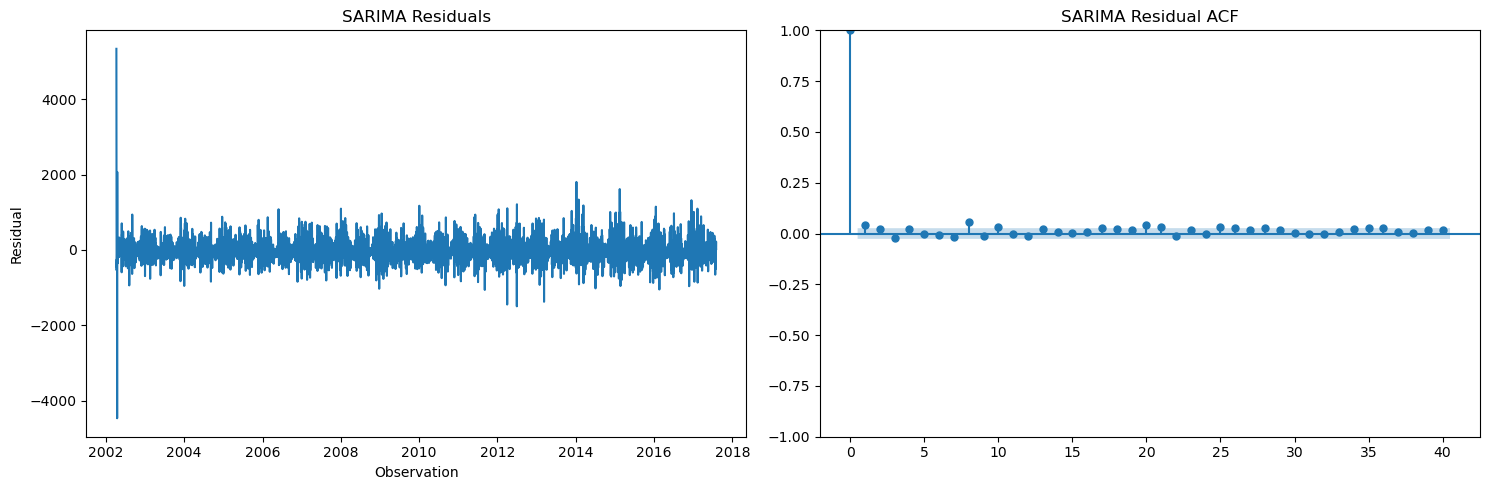

,lb_stat,lb_pvalue
7,20.946774,3.849730e-03
14,48.862840,9.453580e-06
21,72.311426,1.490168e-07
28,90.015391,1.971636e-08


In [74]:
# ============================================================
# SARIMA RESIDUAL DIAGNOSTICS
# ============================================================

sarima_residuals = sarima_fit.resid.dropna()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

axes[0].plot(sarima_residuals)
axes[0].set_title("SARIMA Residuals")
axes[0].set_xlabel("Observation")
axes[0].set_ylabel("Residual")

plot_acf(
    sarima_residuals,
    lags=40,
    ax=axes[1]
)

axes[1].set_title("SARIMA Residual ACF")

plt.tight_layout()
plt.show()

ljung_box_sarima = acorr_ljungbox(
    sarima_residuals,
    lags=[7, 14, 21, 28],
    return_df=True
)

display(ljung_box_sarima)

##  SARIMA TEST-PERIOD FORECAST

In [75]:
sarima_test_result = (
    sarima_fit.get_forecast(
        steps=len(test_daily)
    )
)

sarima_test_mean = (
    sarima_test_result.predicted_mean
)

sarima_test_ci = (
    sarima_test_result.conf_int()
)

sarima_test_forecast_df = pd.DataFrame(
    {
        "Actual": test_daily.values,
        "Forecast": sarima_test_mean.values,
        "Lower_CI": sarima_test_ci.iloc[:, 0].values,
        "Upper_CI": sarima_test_ci.iloc[:, 1].values
    },
    index=test_daily.index
)

sarima_test_forecast_df.index.name = "Date"

display(
    sarima_test_forecast_df.head(10)
)

,Actual,Forecast,Lower_CI,Upper_CI
Date,,,,
2017-08-04,6108.875000,6030.272530,5488.968129,6571.576931
2017-08-05,4997.000000,5579.111501,4797.090648,6361.132355
2017-08-06,4653.291667,5402.029404,4532.823527,6271.235282
2017-08-07,5245.791667,5894.096788,4981.634747,6806.558829
2017-08-08,5461.625000,5968.641839,5029.858743,6907.424936
2017-08-09,5462.750000,5952.738214,4995.280336,6910.196093
2017-08-10,5432.083333,5942.696005,4970.473920,6914.918091
2017-08-11,5647.041667,5860.296722,4875.107643,6845.485800
2017-08-12,5450.041667,5469.317218,4472.606619,6466.027817


###  SARIMA TEST FORECAST VISUALIZATION

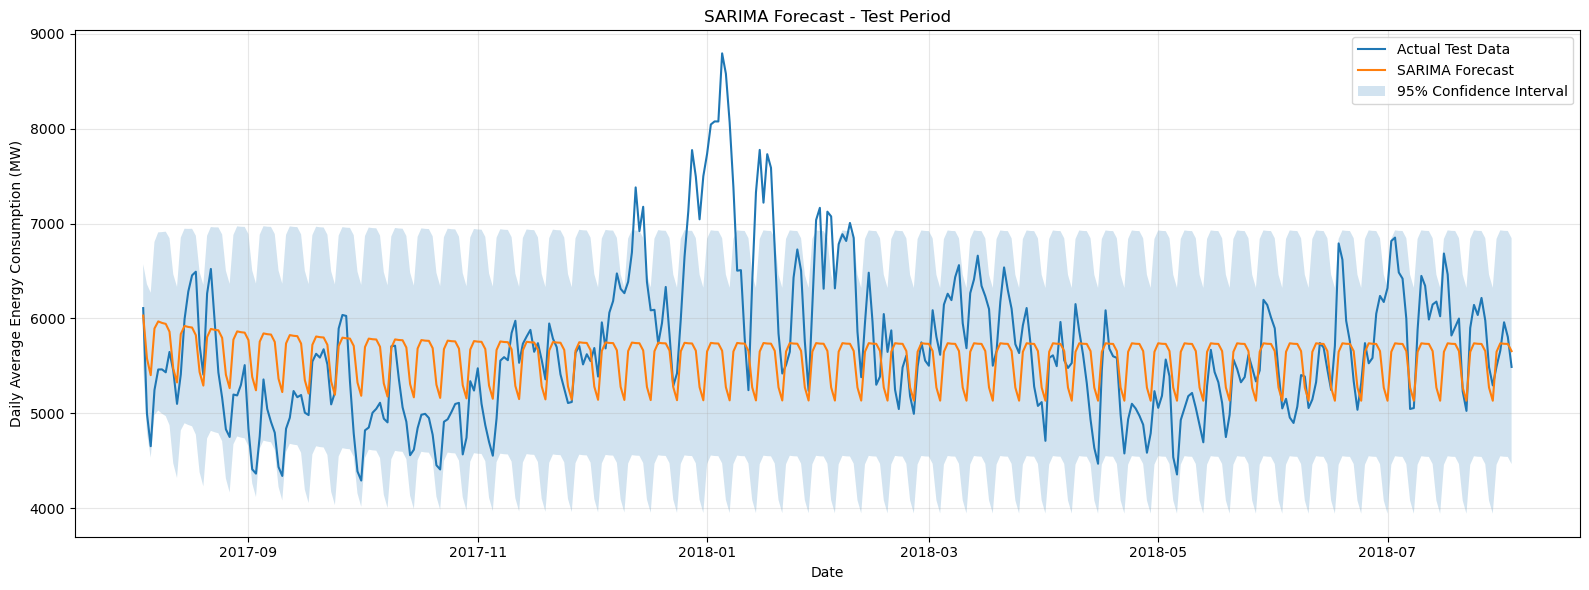

In [76]:

plt.figure(figsize=(16, 6))

plt.plot(
    test_daily.index,
    test_daily.values,
    label="Actual Test Data"
)

plt.plot(
    sarima_test_forecast_df.index,
    sarima_test_forecast_df["Forecast"],
    label="SARIMA Forecast"
)

plt.fill_between(
    sarima_test_forecast_df.index,
    sarima_test_forecast_df["Lower_CI"],
    sarima_test_forecast_df["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(
    "SARIMA Forecast - Test Period"
)

plt.xlabel("Date")
plt.ylabel(
    "Daily Average Energy Consumption (MW)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##  ARIMA - NEXT 30 DAYS FORECAST

In [77]:
arima_full_fit = ARIMA(
    daily,
    order=best_arima_order
).fit()

arima_future_result = (
    arima_full_fit.get_forecast(
        steps=30
    )
)

arima_future_mean = (
    arima_future_result.predicted_mean
)

arima_future_ci = (
    arima_future_result.conf_int()
)

future_dates = pd.date_range(
    start=daily.index.max()
    + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

arima_30_day_forecast = pd.DataFrame(
    {
        "Forecast": arima_future_mean.values,
        "Lower_CI": arima_future_ci.iloc[:, 0].values,
        "Upper_CI": arima_future_ci.iloc[:, 1].values
    },
    index=future_dates
)

arima_30_day_forecast.index.name = "Date"

display(
    arima_30_day_forecast
)

,Forecast,Lower_CI,Upper_CI
Date,,,
2018-08-04,5463.667971,4781.165968,6146.169975
2018-08-05,5554.684882,4562.110474,6547.259290
2018-08-06,5621.002649,4550.322361,6691.682937
2018-08-07,5647.369034,4558.139531,6736.598536
2018-08-08,5645.249156,4547.807029,6742.691283
2018-08-09,5632.070353,4524.416236,6739.724471
2018-08-10,5619.975251,4496.155499,6743.795002
2018-08-11,5613.515760,4468.569614,6758.461905
2018-08-12,5612.075292,4444.720690,6779.429894


## SARIMA - NEXT 30 DAYS FORECAST

In [78]:
sarima_full_fit = SARIMAX(
    daily,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(
    disp=False
)

sarima_future_result = (
    sarima_full_fit.get_forecast(
        steps=30
    )
)

sarima_future_mean = (
    sarima_future_result.predicted_mean
)

sarima_future_ci = (
    sarima_future_result.conf_int()
)

sarima_30_day_forecast = pd.DataFrame(
    {
        "Forecast": sarima_future_mean.values,
        "Lower_CI": sarima_future_ci.iloc[:, 0].values,
        "Upper_CI": sarima_future_ci.iloc[:, 1].values
    },
    index=future_dates
)

sarima_30_day_forecast.index.name = "Date"

display(
    sarima_30_day_forecast
)

,Forecast,Lower_CI,Upper_CI
Date,,,
2018-08-04,5146.122438,4441.234152,5851.010723
2018-08-05,5093.303904,4049.753727,6136.854082
2018-08-06,5637.642701,4460.272285,6815.013117
2018-08-07,5758.252968,4509.490888,7007.015049
2018-08-08,5766.556183,4472.057648,7061.054717
2018-08-09,5759.900624,4431.906807,7087.894441
2018-08-10,5692.306854,4337.355458,7047.258251
2018-08-11,5328.784903,3949.943708,6707.626099
2018-08-12,5195.118434,3794.882401,6595.354468


## ARIMA - NEXT 30 DAYS VISUALIZATION

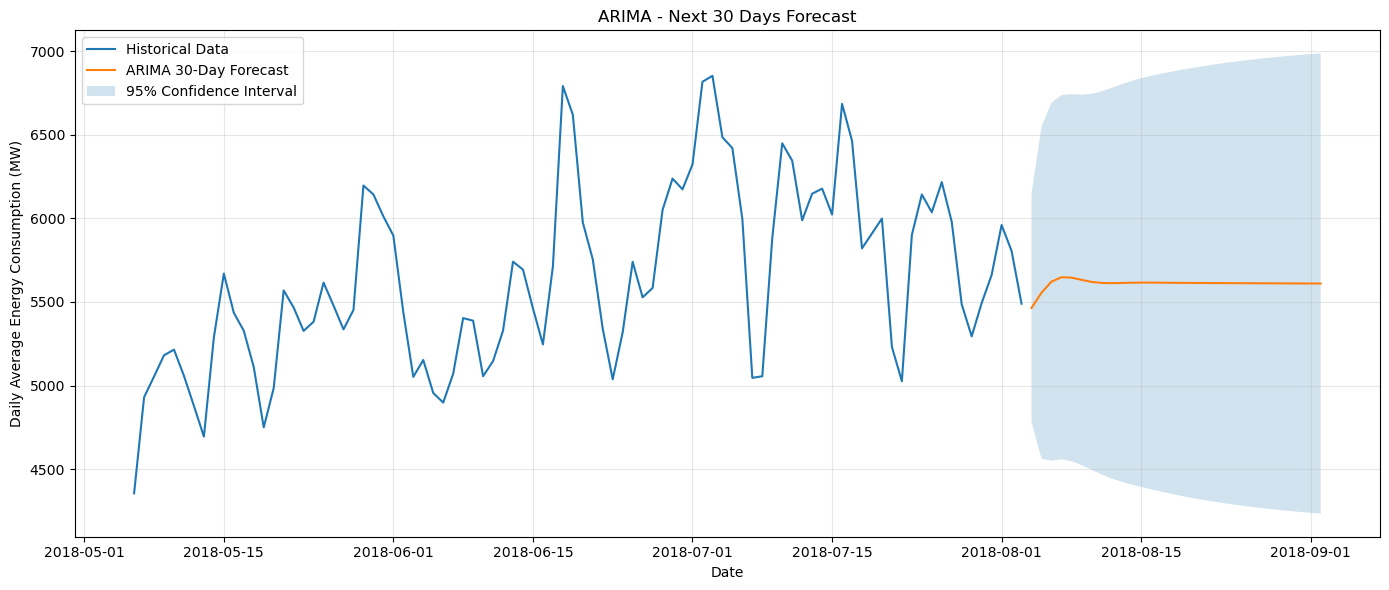

In [79]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily.iloc[-90:].index,
    daily.iloc[-90:].values,
    label="Historical Data"
)

plt.plot(
    arima_30_day_forecast.index,
    arima_30_day_forecast["Forecast"],
    label="ARIMA 30-Day Forecast"
)

plt.fill_between(
    arima_30_day_forecast.index,
    arima_30_day_forecast["Lower_CI"],
    arima_30_day_forecast["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(
    "ARIMA - Next 30 Days Forecast"
)

plt.xlabel("Date")
plt.ylabel(
    "Daily Average Energy Consumption (MW)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## SARIMA - NEXT 30 DAYS VISUALIZATION

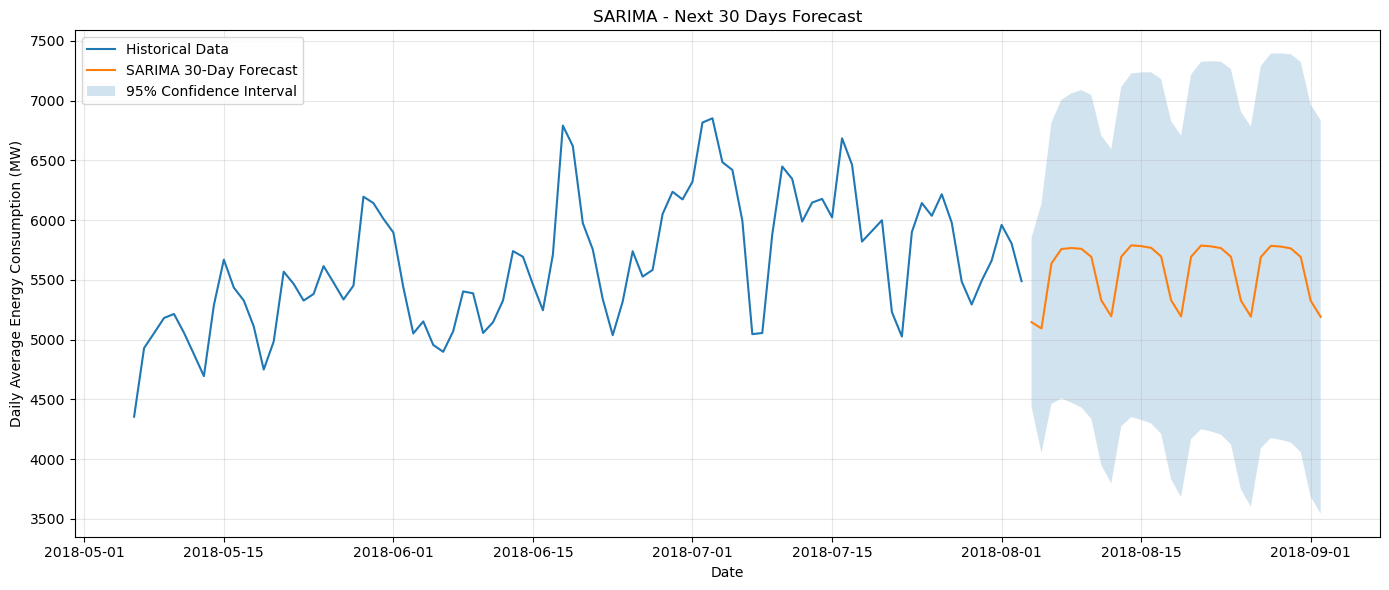

In [80]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily.iloc[-90:].index,
    daily.iloc[-90:].values,
    label="Historical Data"
)

plt.plot(
    sarima_30_day_forecast.index,
    sarima_30_day_forecast["Forecast"],
    label="SARIMA 30-Day Forecast"
)

plt.fill_between(
    sarima_30_day_forecast.index,
    sarima_30_day_forecast["Lower_CI"],
    sarima_30_day_forecast["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(
    "SARIMA - Next 30 Days Forecast"
)

plt.xlabel("Date")
plt.ylabel(
    "Daily Average Energy Consumption (MW)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [81]:
# ============================================================
# SAVE FORECAST RESULTS
# ============================================================

arima_test_forecast_df.to_csv(
    "arima_forecast_test_period.csv"
)

sarima_test_forecast_df.to_csv(
    "sarima_forecast_test_period.csv"
)

arima_30_day_forecast.to_csv(
    "arima_forecast_next_30_days.csv"
)

sarima_30_day_forecast.to_csv(
    "sarima_forecast_next_30_days.csv"
)

print(
    "All forecast files saved successfully."
)

print("\nFiles created:")

print(
    "1. arima_forecast_test_period.csv"
)

print(
    "2. sarima_forecast_test_period.csv"
)

print(
    "3. arima_forecast_next_30_days.csv"
)

print(
    "4. sarima_forecast_next_30_days.csv"
)

All forecast files saved successfully.

Files created:
1. arima_forecast_test_period.csv
2. sarima_forecast_test_period.csv
3. arima_forecast_next_30_days.csv
4. sarima_forecast_next_30_days.csv


## FINAL ARIMA / SARIMA MODELING SUMMARY

In [82]:
print("=" * 65)
print("ARIMA / SARIMA MODELING SUMMARY")
print("=" * 65)

print("\nModeling Dataset:")
print("EDA-prepared daily average PJM energy consumption")

print("\nModeling Frequency:")
print("Daily")

print("\nTotal Observations:")
print(len(daily))

print("\nTraining Observations:")
print(len(train_daily))

print("\nTesting Observations:")
print(len(test_daily))

print("\nTraining Period:")
print(
    train_daily.index.min(),
    "to",
    train_daily.index.max()
)

print("\nTesting Period:")
print(
    test_daily.index.min(),
    "to",
    test_daily.index.max()
)

print("\nSelected ARIMA Order:")
print(best_arima_order)

print("\nSelected SARIMA Order:")
print(best_sarima_order)

print("\nSelected SARIMA Seasonal Order:")
print(best_sarima_seasonal)

print("\nSeasonal Period:")
print(f"{s} days = 1 week")

print("\nForecast Horizon:")
print("30 days")

print("\nFinal Evaluation Metrics:")
print(
    "Not calculated in this modeling section."
)

print(
    "Reserved for the model evaluation/comparison stage."
)

print("\nModel building completed successfully.")

ARIMA / SARIMA MODELING SUMMARY

Modeling Dataset:
EDA-prepared daily average PJM energy consumption

Modeling Frequency:
Daily

Total Observations:
5962

Training Observations:
5597

Testing Observations:
365

Training Period:
2002-04-08 00:00:00 to 2017-08-03 00:00:00

Testing Period:
2017-08-04 00:00:00 to 2018-08-03 00:00:00

Selected ARIMA Order:
(3, 0, 3)

Selected SARIMA Order:
(2, 0, 2)

Selected SARIMA Seasonal Order:
(0, 1, 1, 7)

Seasonal Period:
7 days = 1 week

Forecast Horizon:
30 days

Final Evaluation Metrics:
Not calculated in this modeling section.
Reserved for the model evaluation/comparison stage.

Model building completed successfully.


# ARIMA/SARIMA Modeling Conclusion

The ARIMA and SARIMA models were developed using the daily-average PJM energy consumption series prepared during the EDA stage.

A chronological train-test split was performed, with the final 365 daily observations reserved as the test period in accordance with the project requirement.

For ARIMA, stationarity was assessed using the Augmented Dickey-Fuller test and the differencing order `d` was selected accordingly. The autoregressive and moving-average parameters were tuned systematically using AIC, and the best-performing parameter combination according to AIC was selected for the final ARIMA model.

For SARIMA, the weekly seasonal pattern identified during EDA was incorporated into the model. Since the modeling data is daily, the seasonal period was set to 7 observations, representing one week. Seasonal differencing was assessed using the ADF test on the seasonally differenced series. The regular and seasonal AR/MA parameters were then tuned using a systematic grid search based on AIC.

The final ARIMA and SARIMA models were fitted using the selected hyperparameters and used to generate forecasts for the held-out test period.

Both models were subsequently fitted using the available daily data to generate forecasts for the next 30 days.

The generated forecast outputs are saved as CSV files for the model evaluation and comparison stage.


# XGBoost Model Building

XGBoost is developed as the third forecasting model for PJM energy consumption.

Unlike ARIMA and SARIMA, XGBoost is a supervised machine-learning algorithm. Therefore, the daily energy consumption series is transformed into a supervised learning problem using calendar, lag and rolling features.

The XGBoost model uses the same EDA-prepared daily-average series and the same chronological training and testing periods used for ARIMA and SARIMA.

The model is tuned using time-series cross-validation, fitted using the selected hyperparameters, and then used to generate forecasts for the complete test period and the next 30 days.

In [83]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [84]:
# Use the same EDA-prepared daily series used by ARIMA and SARIMA

xgb_daily = daily.copy()

xgb_daily = xgb_daily.sort_index()

print("XGBoost modeling frequency: Daily")
print("Number of observations:", len(xgb_daily))
print("Start date:", xgb_daily.index.min())
print("End date:", xgb_daily.index.max())

XGBoost modeling frequency: Daily
Number of observations: 5962
Start date: 2002-04-08 00:00:00
End date: 2018-08-03 00:00:00


## XGBoost Feature Engineering

The XGBoost model requires predictor variables because it is a supervised machine-learning model.

Daily calendar features are created to capture recurring time patterns.

Lag features provide information about previous energy consumption, while rolling features summarize recent consumption behavior.

The target variable is the daily average PJM energy consumption.

The features are created only from historical observations so that future target information is not used during forecasting.

In [85]:
xgb_data = pd.DataFrame(index=xgb_daily.index)

# Calendar features
xgb_data["day_of_week"] = xgb_daily.index.dayofweek
xgb_data["day_of_month"] = xgb_daily.index.day
xgb_data["month"] = xgb_daily.index.month
xgb_data["quarter"] = xgb_daily.index.quarter
xgb_data["day_of_year"] = xgb_daily.index.dayofyear
xgb_data["week_of_year"] = xgb_daily.index.isocalendar().week.astype(int)

# Lag features
xgb_data["lag_1"] = xgb_daily.shift(1)
xgb_data["lag_2"] = xgb_daily.shift(2)
xgb_data["lag_3"] = xgb_daily.shift(3)
xgb_data["lag_7"] = xgb_daily.shift(7)
xgb_data["lag_14"] = xgb_daily.shift(14)
xgb_data["lag_30"] = xgb_daily.shift(30)

# Rolling features
xgb_data["rolling_mean_7"] = xgb_daily.shift(1).rolling(7).mean()
xgb_data["rolling_mean_14"] = xgb_daily.shift(1).rolling(14).mean()
xgb_data["rolling_mean_30"] = xgb_daily.shift(1).rolling(30).mean()

# Target
xgb_data["Target"] = xgb_daily

print("XGBoost daily feature dataset created.")
print("Shape:", xgb_data.shape)

XGBoost daily feature dataset created.
Shape: (5962, 16)


In [86]:
xgb_data = xgb_data.dropna()

print("After removing initial missing lag/rolling values:")
print("Observations:", len(xgb_data))
print("Start date:", xgb_data.index.min())
print("End date:", xgb_data.index.max())

After removing initial missing lag/rolling values:
Observations: 5932
Start date: 2002-05-08 00:00:00
End date: 2018-08-03 00:00:00


In [87]:
xgb_features = [
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "day_of_year",
    "week_of_year",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30"
]

X_xgb = xgb_data[xgb_features].copy()
y_xgb = xgb_data["Target"].copy()

print("Number of XGBoost features:", len(xgb_features))
print("Features:")
print(xgb_features)

Number of XGBoost features: 15
Features:
['day_of_week', 'day_of_month', 'month', 'quarter', 'day_of_year', 'week_of_year', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30']


## XGBoost train/test 

In [88]:
xgb_train_mask = xgb_data.index < test_daily.index.min()

xgb_test_mask = (
    (xgb_data.index >= test_daily.index.min()) &
    (xgb_data.index <= test_daily.index.max())
)

X_xgb_train = X_xgb.loc[xgb_train_mask]
X_xgb_test = X_xgb.loc[xgb_test_mask]

y_xgb_train = y_xgb.loc[xgb_train_mask]
y_xgb_test = y_xgb.loc[xgb_test_mask]

print("=" * 60)
print("XGBoost Train/Test Split")
print("=" * 60)

print("\nTraining period:")
print(
    X_xgb_train.index.min(),
    "to",
    X_xgb_train.index.max()
)

print("\nTesting period:")
print(
    X_xgb_test.index.min(),
    "to",
    X_xgb_test.index.max()
)

print("\nTraining observations:", len(X_xgb_train))
print("Testing observations:", len(X_xgb_test))

XGBoost Train/Test Split

Training period:
2002-05-08 00:00:00 to 2017-08-03 00:00:00

Testing period:
2017-08-04 00:00:00 to 2018-08-03 00:00:00

Training observations: 5567
Testing observations: 365


## Validate split

In [89]:
print("\nARIMA/SARIMA test period:")
print(
    test_daily.index.min(),
    "to",
    test_daily.index.max()
)

print("\nXGBoost test period:")
print(
    X_xgb_test.index.min(),
    "to",
    X_xgb_test.index.max()
)

assert X_xgb_test.index.min() == test_daily.index.min()
assert X_xgb_test.index.max() == test_daily.index.max()

print("\nXGBoost test period matches ARIMA and SARIMA test period.")


ARIMA/SARIMA test period:
2017-08-04 00:00:00 to 2018-08-03 00:00:00

XGBoost test period:
2017-08-04 00:00:00 to 2018-08-03 00:00:00

XGBoost test period matches ARIMA and SARIMA test period.


## XGBoost Hyperparameter Tuning

The XGBoost hyperparameters are tuned using time-series cross-validation.

Because the data is time-dependent, `TimeSeriesSplit` is used instead of random cross-validation so that observations from the future are not used to train earlier observations.

The tuning process uses RMSE as the cross-validation scoring criterion.

The selected hyperparameters are then used to fit the final XGBoost model on the complete training portion of the data.

The final model is evaluated separately on the held-out 365-day test period using the same evaluation metrics as ARIMA and SARIMA.

Note that hyperparameter tuning uses time-series cross-validation, while the final test forecast is generated recursively, with each predicted day becoming part of the historical input for subsequent predictions.

In [90]:
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print("Base XGBoost model created.")

Base XGBoost model created.


In [91]:
# ============================================================
# XGBOOST HYPERPARAMETER TUNING
# ============================================================

tscv = TimeSeriesSplit(n_splits=3)

xgb_param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(
    X_xgb_train,
    y_xgb_train
)

print("\nBest XGBoost parameters:")
print(xgb_grid.best_params_)

print("\nBest cross-validation RMSE:")
print(-xgb_grid.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best XGBoost parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}

Best cross-validation RMSE:
305.7980255823038


## Top XGBoost configurations

In [92]:
xgb_results = pd.DataFrame(
    xgb_grid.cv_results_
)

xgb_results["RMSE"] = (
    -xgb_results["mean_test_score"]
)

xgb_results = (
    xgb_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(
    xgb_results[
        [
            "param_n_estimators",
            "param_max_depth",
            "param_learning_rate",
            "param_subsample",
            "param_colsample_bytree",
            "RMSE"
        ]
    ].head(10)
)

,param_n_estimators,param_max_depth,param_learning_rate,param_subsample,param_colsample_bytree,RMSE
0,500,3,0.05,0.8,0.8,305.798026
1,300,3,0.05,0.8,0.8,305.938452
2,300,3,0.10,0.8,0.8,308.170061
3,500,3,0.10,0.8,0.8,311.598541
4,300,5,0.05,0.8,0.8,314.386159
5,500,5,0.05,0.8,0.8,315.766969
6,300,5,0.10,0.8,0.8,318.613622
7,500,5,0.10,0.8,0.8,320.431978


## Final XGBoost Model

After hyperparameter tuning, the configuration with the lowest time-series cross-validation RMSE is selected.

The final XGBoost model is fitted using all available training observations for which the required lag and rolling features can be calculated.

The fitted model is then used to generate recursive forecasts for the complete 365-day test period.

In [93]:
# ============================================================
# FINAL XGBOOST MODEL
# ============================================================

best_xgb_params = xgb_grid.best_params_

final_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **best_xgb_params
)

final_xgb.fit(
    X_xgb_train,
    y_xgb_train
)

print("Final XGBoost model fitted successfully.")

print("\nSelected hyperparameters:")
print(best_xgb_params)

Final XGBoost model fitted successfully.

Selected hyperparameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}


## XGBoost 365-day test forecast

In [94]:
# Recursive daily forecasting for the complete test period

xgb_history = xgb_daily.loc[
    xgb_daily.index < test_daily.index.min()
].copy()

xgb_test_predictions = []

for current_date in test_daily.index:

    feature_row = pd.DataFrame(
        index=[current_date]
    )

    # Calendar features
    feature_row["day_of_week"] = current_date.dayofweek
    feature_row["day_of_month"] = current_date.day
    feature_row["month"] = current_date.month
    feature_row["quarter"] = current_date.quarter
    feature_row["day_of_year"] = current_date.dayofyear
    feature_row["week_of_year"] = current_date.isocalendar().week

    # Lag features
    feature_row["lag_1"] = xgb_history.iloc[-1]

    feature_row["lag_2"] = (
        xgb_history.iloc[-2]
        if len(xgb_history) >= 2 else np.nan
    )

    feature_row["lag_3"] = (
        xgb_history.iloc[-3]
        if len(xgb_history) >= 3 else np.nan
    )

    feature_row["lag_7"] = (
        xgb_history.iloc[-7]
        if len(xgb_history) >= 7 else np.nan
    )

    feature_row["lag_14"] = (
        xgb_history.iloc[-14]
        if len(xgb_history) >= 14 else np.nan
    )

    feature_row["lag_30"] = (
        xgb_history.iloc[-30]
        if len(xgb_history) >= 30 else np.nan
    )

    # Rolling features
    feature_row["rolling_mean_7"] = (
        xgb_history.tail(7).mean()
    )

    feature_row["rolling_mean_14"] = (
        xgb_history.tail(14).mean()
    )

    feature_row["rolling_mean_30"] = (
        xgb_history.tail(30).mean()
    )

    # Ensure feature order is identical to training
    feature_row = feature_row[xgb_features]

    prediction = final_xgb.predict(
        feature_row
    )[0]

    xgb_test_predictions.append(prediction)

    # Add prediction to history for the next day
    xgb_history.loc[current_date] = prediction

In [95]:
# ============================================================
# XGBOOST FORECAST DATAFRAME
# ============================================================

xgb_test_forecast_df = pd.DataFrame(
    {
        "Actual": test_daily.values,
        "Forecast": xgb_test_predictions
    },
    index=test_daily.index
)

xgb_test_forecast_df.index.name = "Datetime"

print("XGBoost test-period forecast:")
display(xgb_test_forecast_df.head(10))

XGBoost test-period forecast:


,Actual,Forecast
Datetime,,
2017-08-04,6108.875000,6061.966309
2017-08-05,4997.000000,5619.733398
2017-08-06,4653.291667,5436.688965
2017-08-07,5245.791667,6021.127930
2017-08-08,5461.625000,6119.899902
2017-08-09,5462.750000,6097.578613
2017-08-10,5432.083333,6061.272949
2017-08-11,5647.041667,5972.281250
2017-08-12,5450.041667,5533.059570


## XGBoost Test-Period Forecast

The following visualization compares the actual daily PJM energy consumption with the XGBoost forecast over the complete 365-day test period.

The forecast is generated recursively, where each predicted day becomes part of the historical information used for subsequent predictions.

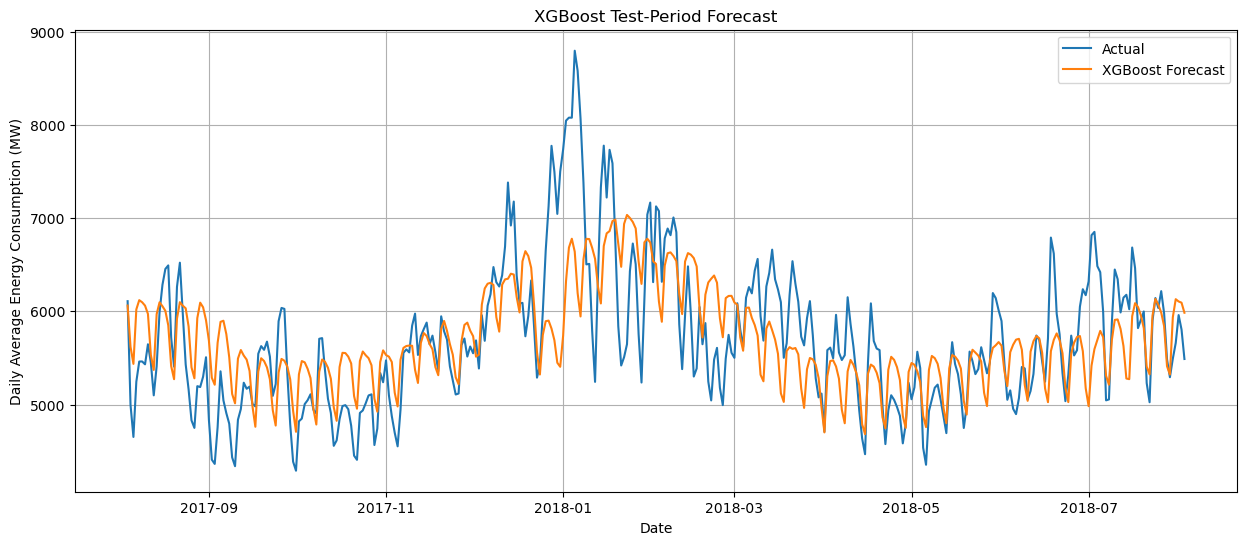

In [96]:
plt.figure(figsize=(15, 6))

plt.plot(
    xgb_test_forecast_df.index,
    xgb_test_forecast_df["Actual"],
    label="Actual"
)

plt.plot(
    xgb_test_forecast_df.index,
    xgb_test_forecast_df["Forecast"],
    label="XGBoost Forecast"
)

plt.title("XGBoost Test-Period Forecast")
plt.xlabel("Date")
plt.ylabel("Daily Average Energy Consumption (MW)")
plt.legend()
plt.grid(True)
plt.show()

## XGBoost 30-day forecast

In [97]:
# Refit the selected XGBoost model using the complete
# available daily series before generating the future forecast.

xgb_full_data = pd.DataFrame(index=xgb_daily.index)

xgb_full_data["day_of_week"] = xgb_daily.index.dayofweek
xgb_full_data["day_of_month"] = xgb_daily.index.day
xgb_full_data["month"] = xgb_daily.index.month
xgb_full_data["quarter"] = xgb_daily.index.quarter
xgb_full_data["day_of_year"] = xgb_daily.index.dayofyear
xgb_full_data["week_of_year"] = (
    xgb_daily.index.isocalendar().week.astype(int)
)

xgb_full_data["lag_1"] = xgb_daily.shift(1)
xgb_full_data["lag_2"] = xgb_daily.shift(2)
xgb_full_data["lag_3"] = xgb_daily.shift(3)
xgb_full_data["lag_7"] = xgb_daily.shift(7)
xgb_full_data["lag_14"] = xgb_daily.shift(14)
xgb_full_data["lag_30"] = xgb_daily.shift(30)

xgb_full_data["rolling_mean_7"] = (
    xgb_daily.shift(1).rolling(7).mean()
)

xgb_full_data["rolling_mean_14"] = (
    xgb_daily.shift(1).rolling(14).mean()
)

xgb_full_data["rolling_mean_30"] = (
    xgb_daily.shift(1).rolling(30).mean()
)

xgb_full_data["Target"] = xgb_daily

xgb_full_data = xgb_full_data.dropna()

X_xgb_full = xgb_full_data[xgb_features]
y_xgb_full = xgb_full_data["Target"]

xgb_future_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    **best_xgb_params
)

xgb_future_model.fit(
    X_xgb_full,
    y_xgb_full
)

print("XGBoost refitted using the complete available daily data.")

XGBoost refitted using the complete available daily data.


In [98]:
# Generate the next 30 daily dates

future_dates = pd.date_range(
    start=xgb_daily.index.max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

xgb_future_history = xgb_daily.copy()

xgb_future_predictions = []

for current_date in future_dates:

    feature_row = pd.DataFrame(
        index=[current_date]
    )

    # Calendar features
    feature_row["day_of_week"] = current_date.dayofweek
    feature_row["day_of_month"] = current_date.day
    feature_row["month"] = current_date.month
    feature_row["quarter"] = current_date.quarter
    feature_row["day_of_year"] = current_date.dayofyear
    feature_row["week_of_year"] = current_date.isocalendar().week

    # Lag features
    feature_row["lag_1"] = xgb_future_history.iloc[-1]
    feature_row["lag_2"] = xgb_future_history.iloc[-2]
    feature_row["lag_3"] = xgb_future_history.iloc[-3]
    feature_row["lag_7"] = xgb_future_history.iloc[-7]
    feature_row["lag_14"] = xgb_future_history.iloc[-14]
    feature_row["lag_30"] = xgb_future_history.iloc[-30]

    # Rolling features
    feature_row["rolling_mean_7"] = (
        xgb_future_history.tail(7).mean()
    )

    feature_row["rolling_mean_14"] = (
        xgb_future_history.tail(14).mean()
    )

    feature_row["rolling_mean_30"] = (
        xgb_future_history.tail(30).mean()
    )

    feature_row = feature_row[xgb_features]

    prediction = xgb_future_model.predict(
        feature_row
    )[0]

    xgb_future_predictions.append(prediction)

    xgb_future_history.loc[current_date] = prediction

In [99]:
xgb_forecast_next_30_days = pd.DataFrame(
    {
        "Forecast": xgb_future_predictions
    },
    index=future_dates
)

xgb_forecast_next_30_days.index.name = "Datetime"

display(
    xgb_forecast_next_30_days
)

,Forecast
Datetime,
2018-08-04,5149.535156
2018-08-05,5038.707031
2018-08-06,5658.264648
2018-08-07,5908.020996
2018-08-08,5936.336426
2018-08-09,5857.444336
2018-08-10,5665.476562
2018-08-11,5330.364746
2018-08-12,5273.563965


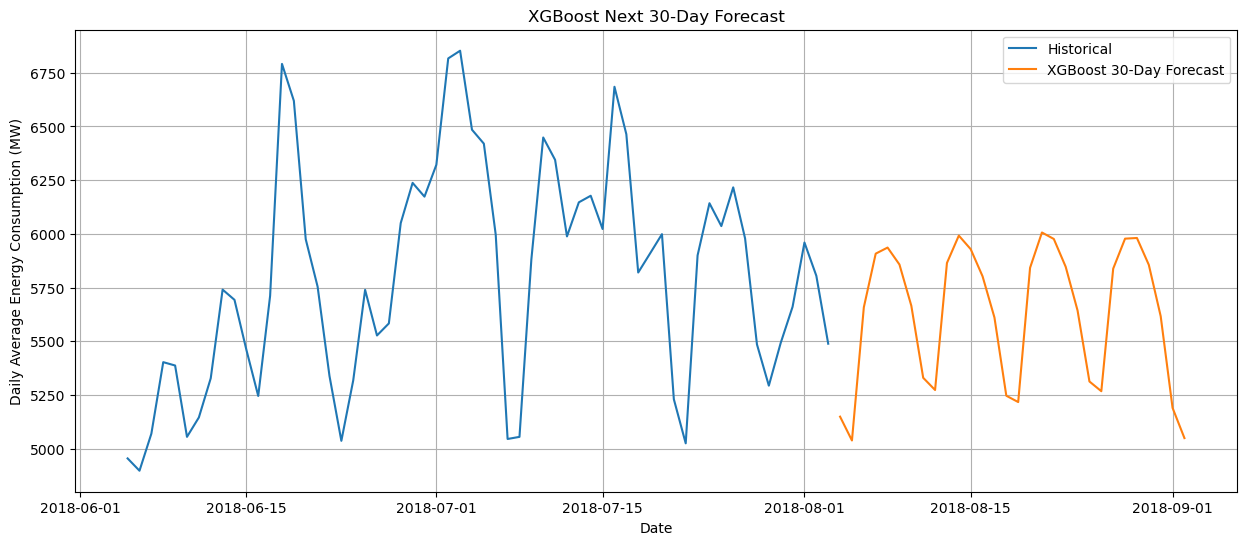

In [100]:
plt.figure(figsize=(15, 6))

plt.plot(
    xgb_daily.tail(60).index,
    xgb_daily.tail(60).values,
    label="Historical"
)

plt.plot(
    xgb_forecast_next_30_days.index,
    xgb_forecast_next_30_days["Forecast"],
    label="XGBoost 30-Day Forecast"
)

plt.title("XGBoost Next 30-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Daily Average Energy Consumption (MW)")
plt.legend()
plt.grid(True)
plt.show()

In [101]:
xgb_test_forecast_df.to_csv(
    "xgboost_forecast_test_period.csv"
)

xgb_forecast_next_30_days.to_csv(
    "xgboost_forecast_next_30_days.csv"
)

print("XGBoost forecast files saved successfully.")

print("\nFiles:")
print("xgboost_forecast_test_period.csv")
print("xgboost_forecast_next_30_days.csv")

XGBoost forecast files saved successfully.

Files:
xgboost_forecast_test_period.csv
xgboost_forecast_next_30_days.csv


#  Model Evaluation and Comparison

## Evaluation Objective

The three forecasting models developed in this project are evaluated on the same held-out test period.

The models are:

- ARIMA
- SARIMA
- XGBoost

The final 365 daily observations are used as the common test period.

The models are compared using five evaluation metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- R² Score

Using the same test observations ensures that the model comparison is performed on a common basis.

In [102]:
# Create a common evaluation dataframe

evaluation_df = pd.DataFrame({
    "Actual": test_daily,
    "ARIMA": arima_test_forecast_df["Forecast"],
    "SARIMA": sarima_test_forecast_df["Forecast"],
    "XGBoost": xgb_test_forecast_df["Forecast"]
})

# Check for missing forecasts
print(evaluation_df.isna().sum())

# Ensure all models have forecasts for the complete test period
assert evaluation_df.isna().sum().sum() == 0

print("=" * 65)
print("COMMON EVALUATION DATASET")
print("=" * 65)

print("\nEvaluation period:")
print(
    evaluation_df.index.min(),
    "to",
    evaluation_df.index.max()
)

print("\nNumber of observations:")
print(len(evaluation_df))

display(evaluation_df.head())

Actual     0
ARIMA      0
SARIMA     0
XGBoost    0
dtype: int64
COMMON EVALUATION DATASET

Evaluation period:
2017-08-04 00:00:00 to 2018-08-03 00:00:00

Number of observations:
365


,Actual,ARIMA,SARIMA,XGBoost
Datetime,,,,
2017-08-04,6108.875000,5943.382031,6030.272530,6061.966309
2017-08-05,4997.000000,5741.249789,5579.111501,5619.733398
2017-08-06,4653.291667,5679.898502,5402.029404,5436.688965
2017-08-07,5245.791667,5703.902467,5894.096788,6021.127930
2017-08-08,5461.625000,5750.905745,5968.641839,6119.899902


In [103]:
# Validate that all models are evaluated on the same test period

assert evaluation_df.index.equals(test_daily.index)

assert len(evaluation_df) == len(test_daily)

assert evaluation_df.index.min() == test_daily.index.min()

assert evaluation_df.index.max() == test_daily.index.max()

print("All three models are aligned with the same 365-day test period.")

All three models are aligned with the same 365-day test period.


## Evaluation Metrics

The forecasting models are evaluated using five metrics.

MAE measures the average absolute difference between the actual and predicted values.

MSE measures the average squared forecasting error and gives greater weight to larger errors.

RMSE is the square root of MSE and represents the forecasting error in the same unit as the target variable.

MAPE measures the average percentage difference between the actual and predicted values.

R² measures how much of the variation in the actual values is explained by the model predictions.

For MAE, MSE, RMSE and MAPE, lower values indicate smaller forecasting errors.

For R², a higher value indicates that the predictions explain more of the variation in the observed values.

In [104]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(mse)

    # Avoid division by zero in MAPE
    non_zero = actual != 0

    mape = np.mean(
        np.abs(
            (actual[non_zero] - predicted[non_zero])
            / actual[non_zero]
        )
    ) * 100

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2
    }

In [105]:
models = [
    "ARIMA",
    "SARIMA",
    "XGBoost"
]

evaluation_results = {}

for model in models:

    evaluation_results[model] = calculate_metrics(
        evaluation_df["Actual"],
        evaluation_df[model]
    )

evaluation_results = pd.DataFrame(
    evaluation_results
).T

evaluation_results.index.name = "Model"

display(
    evaluation_results.round(4)
)

,MAE,MSE,RMSE,MAPE (%),R2
Model,,,,,
ARIMA,586.4204,607012.7334,779.1102,10.0614,-0.0340
SARIMA,565.5910,574782.0326,758.1438,9.5890,0.0209
XGBoost,455.2277,363016.4746,602.5085,7.8235,0.3816


In [106]:
print("=" * 65)
print("METRIC INTERPRETATION")
print("=" * 65)

print("\nLower values indicate smaller forecasting errors:")
print("- MAE")
print("- MSE")
print("- RMSE")
print("- MAPE")

print("\nHigher values indicate better explained variation:")
print("- R²")

METRIC INTERPRETATION

Lower values indicate smaller forecasting errors:
- MAE
- MSE
- RMSE
- MAPE

Higher values indicate better explained variation:
- R²


## ## Actual vs Forecast Comparison

The following visualization compares the actual daily PJM energy consumption with the forecasts generated by ARIMA, SARIMA and XGBoost over the common test period.

This allows the forecasting behavior of the three models to be compared visually.

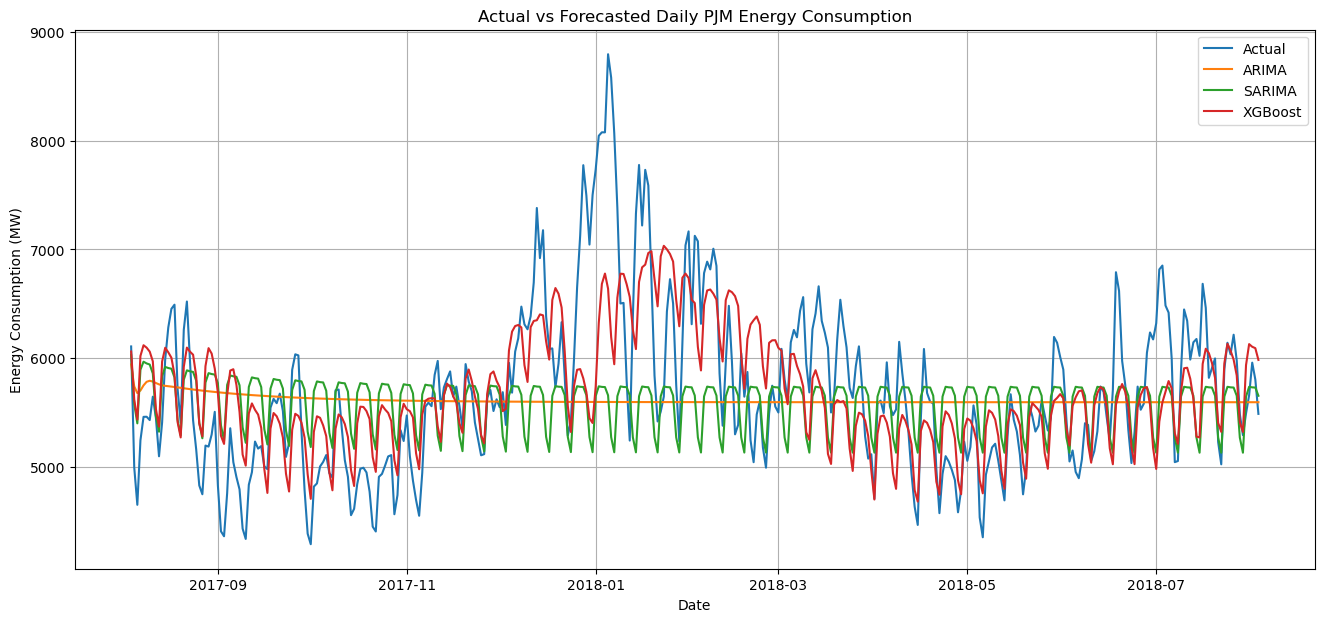

In [107]:
plt.figure(figsize=(16, 7))

plt.plot(
    evaluation_df.index,
    evaluation_df["Actual"],
    label="Actual"
)

plt.plot(
    evaluation_df.index,
    evaluation_df["ARIMA"],
    label="ARIMA"
)

plt.plot(
    evaluation_df.index,
    evaluation_df["SARIMA"],
    label="SARIMA"
)

plt.plot(
    evaluation_df.index,
    evaluation_df["XGBoost"],
    label="XGBoost"
)

plt.title(
    "Actual vs Forecasted Daily PJM Energy Consumption"
)

plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")

plt.legend()
plt.grid(True)

plt.show()

## Forecast Error Comparison

The following visualization compares the forecasting errors of the three models using MAE, RMSE and MAPE.

These metrics provide a direct comparison of the magnitude of the forecasting errors on the common test period.

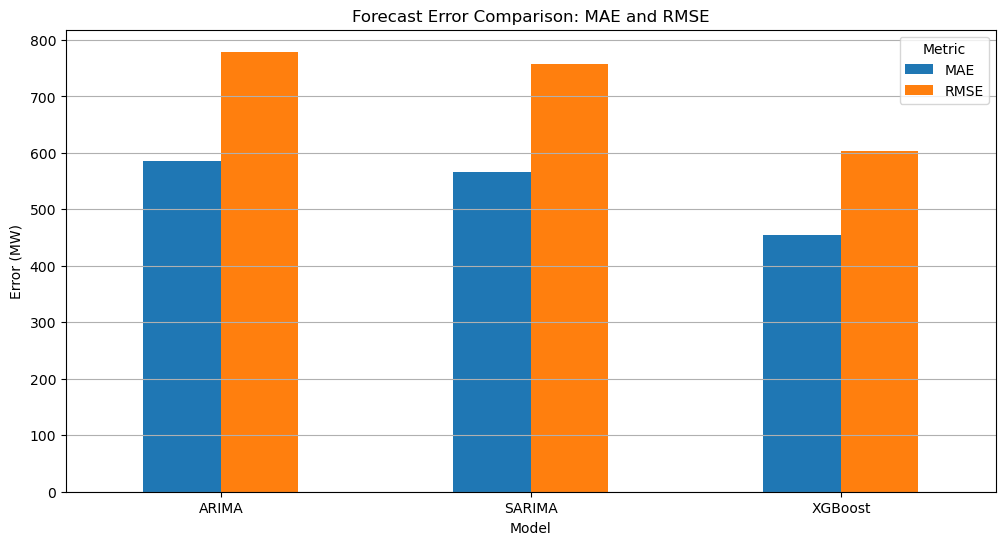

In [108]:
error_metrics = evaluation_results[
    ["MAE", "RMSE"]
]

error_metrics.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Forecast Error Comparison: MAE and RMSE")
plt.xlabel("Model")
plt.ylabel("Error (MW)")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y")

plt.show()

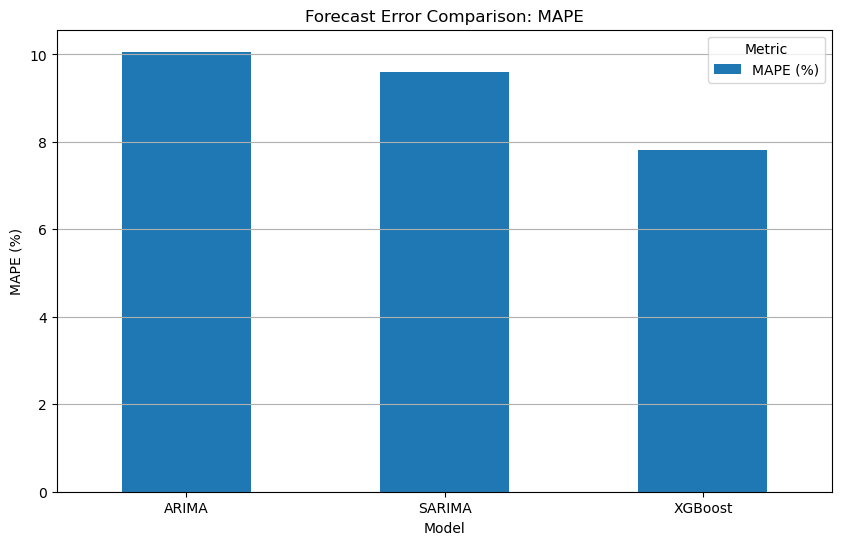

In [109]:
mape_metrics = evaluation_results[
    ["MAPE (%)"]
]

mape_metrics.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Forecast Error Comparison: MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y")

plt.show()

## R² Comparison

R² is examined separately because, unlike MAE, MSE, RMSE and MAPE, a higher R² value indicates that more variation in the observed energy consumption is explained by the model predictions.

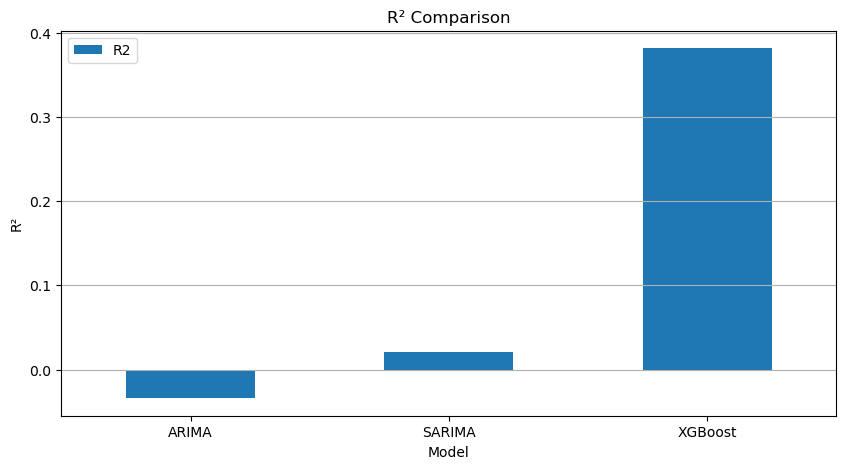

In [110]:
r2_values = evaluation_results[
    ["R2"]
]

r2_values.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("R² Comparison")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

## Final Model Comparison

The final evaluation table summarizes the performance of ARIMA, SARIMA and XGBoost on the same held-out test period.

The comparison is based on MAE, MSE, RMSE, MAPE and R².

In [111]:
print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(
    evaluation_results.round(4)
)

print("\nEvaluation period:")
print(
    evaluation_df.index.min(),
    "to",
    evaluation_df.index.max()
)

print("\nNumber of evaluation observations:")
print(len(evaluation_df))

FINAL MODEL COMPARISON


,MAE,MSE,RMSE,MAPE (%),R2
Model,,,,,
ARIMA,586.4204,607012.7334,779.1102,10.0614,-0.0340
SARIMA,565.5910,574782.0326,758.1438,9.5890,0.0209
XGBoost,455.2277,363016.4746,602.5085,7.8235,0.3816



Evaluation period:
2017-08-04 00:00:00 to 2018-08-03 00:00:00

Number of evaluation observations:
365


In [112]:
print("=" * 65)
print("METRIC-WISE RESULTS")
print("=" * 65)

print(
    "\nLowest MAE:",
    evaluation_results["MAE"].idxmin()
)

print(
    "Lowest MSE:",
    evaluation_results["MSE"].idxmin()
)

print(
    "Lowest RMSE:",
    evaluation_results["RMSE"].idxmin()
)

print(
    "Lowest MAPE:",
    evaluation_results["MAPE (%)"].idxmin()
)

print(
    "Highest R²:",
    evaluation_results["R2"].idxmax()
)

METRIC-WISE RESULTS

Lowest MAE: XGBoost
Lowest MSE: XGBoost
Lowest RMSE: XGBoost
Lowest MAPE: XGBoost
Highest R²: XGBoost


# Final Model Selection

Based on the evaluation of ARIMA, SARIMA, and XGBoost on the same 365-day test period, **XGBoost is selected as the final model for deployment**.

The selection considers not only the forecasting performance measured using MAE, MSE, RMSE, MAPE, and R², but also the suitability of the model for practical deployment. XGBoost can incorporate time-based and lag-based features such as day of the week, month, previous-day consumption, weekly and monthly lags, and rolling averages. This allows the model to capture nonlinear relationships and changing consumption patterns in the PJM energy data.

ARIMA and SARIMA provide important statistical forecasting benchmarks and help capture temporal and seasonal dependencies. However, XGBoost provides a flexible feature-based forecasting approach that can be extended with additional explanatory variables in a future deployment.

Therefore, **XGBoost is selected as the final model for deployment**, while ARIMA and SARIMA are retained as benchmark models for comparison and validation.
